# **Import Libraries and Setup**

In [6]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from matplotlib.ticker import FuncFormatter, LogLocator
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# **Load Datasets**

In [7]:
# loading datasets
basics_df     = pd.read_csv("title.basics.tsv", sep="\t", na_values="\\N")
ratings_df    = pd.read_csv("title.ratings.tsv", sep="\t", na_values="\\N")
crew_df       = pd.read_csv("title.crew.tsv", sep="\t", na_values="\\N")
akas_df       = pd.read_csv("title.akas.filtered.tsv", sep="\t", na_values="\\N")
names_df      = pd.read_csv("name.basics.tsv", sep="\t", na_values="\\N")
principals_df = pd.read_csv("title.principals.cleaned.tsv", sep="\t", na_values="\\N")

print("Datasets loaded successfully")

Datasets loaded successfully


# **Missing Values Inspection**

In [ ]:
#  check missing value percentages in each column
def print_missing_percentages(df, df_name):
    print(f"📊 Missing Values in {df_name}:")
    missing_percent = df.replace("\\N", pd.NA).isnull().mean() * 100
    print(missing_percent[missing_percent > 0].sort_values(ascending=False).round(2))
    print("-" * 50)

# Apply the function to all dataframes
print_missing_percentages(akas_df, "akas_df")
print_missing_percentages(basics_df, "basics_df")
print_missing_percentages(crew_df, "crew_df")
print_missing_percentages(ratings_df, "ratings_df")
print_missing_percentages(names_df, "names_df")

📊 Missing Values in akas_df:
attributes    96.51
language      87.35
region        32.26
types         17.64
title          0.00
dtype: float64
--------------------------------------------------
📊 Missing Values in basics_df:
endYear           98.79
runtimeMinutes    67.14
startYear         12.29
genres             4.43
primaryTitle       0.00
originalTitle      0.00
isAdult            0.00
dtype: float64
--------------------------------------------------
📊 Missing Values in crew_df:
writers      49.27
directors    43.46
dtype: float64
--------------------------------------------------
📊 Missing Values in ratings_df:
Series([], dtype: float64)
--------------------------------------------------
📊 Missing Values in names_df:
deathYear            98.31
birthYear            95.51
primaryProfession    19.66
knownForTitles       11.49
primaryName           0.00
dtype: float64
--------------------------------------------------


In [ ]:
# Load only necessary columns and set NA values
usecols = ['tconst', 'genres']
basics_df_test = pd.read_csv("title.basics.tsv", sep="\t", usecols=usecols, na_values="\\N")
ratings_df_test = pd.read_csv("title.ratings.tsv", sep="\t", na_values="\\N")

# Merge on 'tconst'
df = pd.merge(basics_df_test, ratings_df_test, on="tconst", how="left")

# Drop rows without genres
df = df.dropna(subset=["genres"])

# Initialize genre stats using defaultdict
genre_stats = defaultdict(lambda: {'count': 0, 'missing_avgRating': 0, 'missing_numVotes': 0})

# Process genres with zip() to avoid dataframe overhead
for genres, avg, votes in zip(df['genres'], df['averageRating'], df['numVotes']):
    genre_list = genres.split(',')
    for genre in genre_list:
        genre_stats[genre]['count'] += 1
        if pd.isna(avg):
            genre_stats[genre]['missing_avgRating'] += 1
        if pd.isna(votes):
            genre_stats[genre]['missing_numVotes'] += 1

# Convert to DataFrame
genre_df = pd.DataFrame.from_dict(genre_stats, orient='index')

# Add percentage columns
genre_df['missing_avgRating_%'] = (genre_df['missing_avgRating'] / genre_df['count']) * 100
genre_df['missing_numVotes_%'] = (genre_df['missing_numVotes'] / genre_df['count']) * 100

# Sort and display
genre_df = genre_df.sort_values(by='missing_avgRating_%', ascending=False)

print("📊 Missing Data Percentage by Genre:\n")
print(genre_df[[
    'count', 'missing_avgRating', 'missing_avgRating_%',
    'missing_numVotes', 'missing_numVotes_%'
]].round(2))

📊 Missing Data Percentage by Genre:

               count  missing_avgRating  missing_avgRating_%  \
News         1096084            1074856                98.06   
Talk-Show    1445678            1401498                96.94   
Adult         372182             348400                93.61   
Game-Show     441061             401527                91.04   
Sport         292908             261190                89.17   
Music         434613             385739                88.75   
Romance      1082357             958194                88.53   
Reality-TV    652285             566469                86.84   
Family        856622             743290                86.77   
Short        1237494            1056419                85.37   
Musical        95144              80646                84.76   
Drama        3276836            2743941                83.74   
Documentary  1108950             907538                81.84   
Comedy       2262931            1778661                78.60   
Fan

In [ ]:
# Load required columns only to reduce memory usage
basics_df_test = pd.read_csv("title.basics.tsv", sep="\t", usecols=['tconst', 'titleType'], na_values="\\N")

# Merge ratings into basics by 'tconst'
df = pd.merge(basics_df_test, ratings_df_test, on='tconst', how='left')

# Drop rows where titleType is missing (optional safety)
df = df.dropna(subset=['titleType'])

# Initialize defaultdict for storing stats
titleType_stats = defaultdict(lambda: {'count': 0, 'missing_avgRating': 0, 'missing_numVotes': 0})

# Efficient row-wise iteration using zip()
for title_type, avg, votes in zip(df['titleType'], df['averageRating'], df['numVotes']):
    titleType_stats[title_type]['count'] += 1
    if pd.isna(avg):
        titleType_stats[title_type]['missing_avgRating'] += 1
    if pd.isna(votes):
        titleType_stats[title_type]['missing_numVotes'] += 1

# Convert to DataFrame
missing_info_by_titleType = pd.DataFrame.from_dict(titleType_stats, orient='index')

# Calculate percentages
missing_info_by_titleType['missing_avgRating_%'] = (
    missing_info_by_titleType['missing_avgRating'] / missing_info_by_titleType['count'] * 100
)
missing_info_by_titleType['missing_numVotes_%'] = (
    missing_info_by_titleType['missing_numVotes'] / missing_info_by_titleType['count'] * 100
)

# Sort by missing percentage
missing_info_by_titleType = missing_info_by_titleType.sort_values(by='missing_avgRating_%', ascending=False)

# Display results
print("📊 Missing Data Percentage by TitleType:\n")
print(missing_info_by_titleType[[
    'count', 'missing_avgRating', 'missing_avgRating_%',
    'missing_numVotes', 'missing_numVotes_%'
]].round(2))


📊 Missing Data Percentage by TitleType:

                count  missing_avgRating  missing_avgRating_%  \
tvPilot             1                  1               100.00   
tvEpisode     8956096            8160743                91.12   
short         1059206             888449                83.88   
video          310253             253683                81.77   
tvShort         10633               8196                77.08   
tvSpecial       52486              39198                74.68   
tvMiniSeries    61551              41162                66.87   
tvMovie        150857              95510                63.31   
tvSeries       281223             177350                63.06   
videoGame       42896              24751                57.70   
movie          714015             384344                53.83   

              missing_numVotes  missing_numVotes_%  
tvPilot                      1              100.00  
tvEpisode              8160743               91.12  
short              

In [ ]:
# Load only necessary columns
basics_df_test = pd.read_csv("title.basics.tsv", sep="\t", usecols=['tconst', 'titleType'], na_values="\\N")
crew_df_test = pd.read_csv("title.crew.tsv", sep="\t", usecols=['tconst', 'directors'], na_values="\\N")

# Merge the datasets on 'tconst'
df = pd.merge(basics_df_test, crew_df_test, on='tconst', how='left')

# Create a boolean column indicating if 'directors' is missing
df['directors_missing'] = df['directors'].isnull()

# Group by titleType and calculate the percentage of missing directors
missing_directors_by_titleType = df.groupby('titleType')['directors_missing'].mean() * 100

# Sort and print
print("🎬 Percentage of Titles Missing Directors Info by Title Type:\n")
print(missing_directors_by_titleType.sort_values(ascending=False).round(2))


🎬 Percentage of Titles Missing Directors Info by Title Type:

titleType
tvPilot         100.00
videoGame        63.95
tvEpisode        51.62
tvSpecial        39.73
video            30.65
tvSeries         30.03
tvMiniSeries     19.32
tvShort          17.89
tvMovie          14.04
movie            10.61
short             9.16
Name: directors_missing, dtype: float64


# **Cleaning**

### title basics

In [ ]:
#  Inspect initial structure 
num_columns = basics_df.shape[1]
print(f"Number of columns: {num_columns}")
print(f"Column names: {basics_df.columns.tolist()}")

#  Drop unnecessary columns 
cols_to_drop = ['endYear', 'runtimeMinutes', 'isAdult']
basics_df = basics_df.drop(columns=cols_to_drop, errors='ignore')

# Confirm structure after drop
num_columns = basics_df.shape[1]
print(f"Number of columns after drop: {num_columns}")
print(f"Remaining columns: {basics_df.columns.tolist()}")

#  Change data type of startYear to datetime 
basics_df['startYear'] = pd.to_datetime(basics_df['startYear'], format='%Y', errors='coerce')

#  Clean genres (replace missing with None) 
basics_df['genres'] = basics_df['genres'].replace('\\N', None)

# printing unique genres
all_genres = []
for genres_str in basics_df['genres'].dropna():
    genres = genres_str.split(',')
    all_genres.extend(genres)

unique_genres = set(all_genres)
print("Unique Genres:", unique_genres)
print("Number of Unique Genres:", len(unique_genres))

#  Filter titleType 
print("Original title types:", basics_df['titleType'].unique())

# Remove 'tvEpisode' and 'tvPilot'
basics_df = basics_df[~basics_df['titleType'].isin(['tvEpisode', 'tvPilot'])]

# Reset index and convert to category
basics_df = basics_df.reset_index(drop=True)
basics_df['titleType'] = basics_df['titleType'].astype('category')

# Confirm filtered types
print("Filtered title types:", basics_df['titleType'].unique())

#  Remove duplicates 
before_dedup = basics_df.shape[0]
basics_df = basics_df.drop_duplicates()
after_dedup = basics_df.shape[0]
print(f"Removed {before_dedup - after_dedup} duplicate rows.")

# Final structure 
print("\nFinal DataFrame info:")
print(basics_df.info())


Number of columns: 9
Column names: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres']
Number of columns after drop: 6
Remaining columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'startYear', 'genres']
Unique Genres: {'Drama', 'Music', 'Reality-TV', 'Musical', 'Adult', 'History', 'Mystery', 'Adventure', 'Game-Show', 'Short', 'Horror', 'Talk-Show', 'Crime', 'News', 'Sci-Fi', 'Family', 'Western', 'War', 'Fantasy', 'Film-Noir', 'Action', 'Biography', 'Documentary', 'Animation', 'Comedy', 'Sport', 'Romance', 'Thriller'}
Number of Unique Genres: 28
Original title types: ['short' 'movie' 'tvShort' 'tvMovie' 'tvEpisode' 'tvSeries' 'tvMiniSeries'
 'tvSpecial' 'video' 'videoGame' 'tvPilot']
Filtered title types: ['short', 'movie', 'tvShort', 'tvMovie', 'tvSeries', 'tvMiniSeries', 'tvSpecial', 'video', 'videoGame']
Categories (9, object): ['movie', 'short', 'tvMiniSeries', 'tvMovie', ..., 'tvShort', 'tvSpecial', 

### title akas

In [ ]:
# Drop 'attributes' and 'language' columns 
akas_df = akas_df.drop(columns=['attributes', 'language'], errors='ignore')

# Replace '\N' with None (interpreted as NaN by pandas) 
akas_df = akas_df.replace('\\N', None)

#  Inspect structure after cleaning 
print("Remaining columns:", akas_df.columns.tolist())
print("Missing values summary:")
print(akas_df.isna().mean().round(4) * 100)

#  Optionally save cleaned version 
akas_df.to_csv("akas_cleaned.tsv", sep='\t', index=False)
print("\n✅ Cleaned akas_df saved to 'akas_cleaned.tsv'")


Remaining columns: ['titleId', 'ordering', 'title', 'region', 'types', 'isOriginalTitle']
Missing values summary:
titleId             0.00
ordering            0.00
title               0.00
region             32.26
types              17.64
isOriginalTitle     0.00
dtype: float64

✅ Cleaned akas_df saved to 'akas_cleaned.tsv'


### title ratings

In [ ]:
# Show initial shapes and columns 
print("title.basics shape:", basics_df.shape)
print("Columns:", basics_df.columns.tolist())
print("title.ratings shape:", ratings_df.shape)
print("Columns:", ratings_df.columns.tolist())

# Remove rows with NaN in averageRating or numVotes 
ratings_df = ratings_df.dropna(subset=['averageRating', 'numVotes'])

# Remove rows where numVotes is zero
ratings_df = ratings_df[ratings_df['numVotes'] > 0]

# Merge cleaned ratings with cleaned basics on 'tconst' 
rating_analysis = pd.merge(basics_df, ratings_df, on='tconst', how='inner')

# Summary before and after cleaning 
print("Number of rows after cleaning ratings:", ratings_df.shape[0])
print("Number of rows in merged dataset:", rating_analysis.shape[0])
print("Merged columns:", rating_analysis.columns.tolist())

title.basics shape: (2683120, 6)
Columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'startYear', 'genres']
title.ratings shape: (1565832, 3)
Columns: ['tconst', 'averageRating', 'numVotes']
Number of rows after cleaning ratings: 1565832
Number of rows in merged dataset: 770477
Merged columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'startYear', 'genres', 'averageRating', 'numVotes']


### title crew

In [ ]:
# Replace '\N' with None (i.e., NaN in pandas) 
crew_df = crew_df.replace('\\N', None)

#  Check missing data summary 
print("Missing values (%):")
print(crew_df.isna().mean().round(4) * 100)

# save cleaned crew_df 
crew_df.to_csv("crew_cleaned.tsv", sep='\t', index=False)
print("\n✅ Cleaned crew_df saved to 'crew_cleaned.tsv'")

Missing values (%):
tconst        0.00
directors    43.46
writers      49.27
dtype: float64

✅ Cleaned crew_df saved to 'crew_cleaned.tsv'


### name basics

In [ ]:
#  Drop 'birthYear' and 'deathYear' columns 
names_df = names_df.drop(columns=['birthYear', 'deathYear'], errors='ignore')

#  Replace '\N' with None (pandas treats it as NaN) 
names_df = names_df.replace('\\N', None)

# Show structure and null summary 
print("Remaining columns:", names_df.columns.tolist())
print("Missing values (%):")
print(names_df.isna().mean().round(4) * 100)

#  Optionally save cleaned names_df 
names_df.to_csv("names_cleaned.tsv", sep='\t', index=False)
print("\n✅ Cleaned names_df saved to 'names_cleaned.tsv'")

Remaining columns: ['nconst', 'primaryName', 'primaryProfession', 'knownForTitles']
Missing values (%):
nconst                0.00
primaryName           0.00
primaryProfession    19.66
knownForTitles       11.49
dtype: float64

✅ Cleaned names_df saved to 'names_cleaned.tsv'


### Title Principals

In [ ]:
"""
input_file = 'title.principals.tsv'
output_file = 'title.principals.cleaned.tsv'

columns_to_keep = ['tconst', 'nconst', 'category']

with open(output_file, 'w', encoding='utf-8') as f_out:
    f_out.write('\t'.join(columns_to_keep) + '\n')


chunk_size = 100_000
reader = pd.read_csv(input_file, sep='\t', dtype=str, chunksize=chunk_size)

for i, chunk in enumerate(reader):
    cleaned_chunk = chunk[columns_to_keep]
    cleaned_chunk.to_csv(output_file, sep='\t', mode='a', header=False, index=False)
    print(f"✅ Processed chunk {i + 1}")
"""


'\ninput_file = \'title.principals.tsv\'\noutput_file = \'title.principals.cleaned.tsv\'\n\n# הגדרת שמות העמודות לשמירה\ncolumns_to_keep = [\'tconst\', \'nconst\', \'category\']\n\n# כתיבה לקובץ יעד ריק עם כותרת\nwith open(output_file, \'w\', encoding=\'utf-8\') as f_out:\n    f_out.write(\'\t\'.join(columns_to_keep) + \'\n\')\n\n# קריאה ועיבוד בצ\'אנקים של 100,000 שורות\nchunk_size = 100_000\nreader = pd.read_csv(input_file, sep=\'\t\', dtype=str, chunksize=chunk_size)\n\nfor i, chunk in enumerate(reader):\n    cleaned_chunk = chunk[columns_to_keep]\n    cleaned_chunk.to_csv(output_file, sep=\'\t\', mode=\'a\', header=False, index=False)\n    print(f"✅ Processed chunk {i + 1}")\n'

# **Mergings**

### df_title_trends + df_genre_counts

In [ ]:
# Load the dataset
df_genre_counts = basics_df.copy()

In [ ]:
df_title_trends = basics_df.copy()

### df_ratings_analysis

In [ ]:
# Show initial shapes and Columns
print("title.basics shape:", basics_df.shape)
print("Columns:", basics_df.columns.tolist())
print("title.ratings shape:", ratings_df.shape)
print("Columns:", ratings_df.columns.tolist())

# Merge on 'tconst'
rating_analysis = pd.merge(basics_df, ratings_df, on='tconst', how='inner')

# Get number of rows before dropping missing ratings
before_drop = rating_analysis.shape[0]
print("Number of rows before dropping missing ratings:", before_drop)

# Drop rows without a rating (averageRating or numVotes is NaN)
rating_analysis = rating_analysis.dropna(subset=['averageRating', 'numVotes'])

# Get number of rows after dropping missing ratings
after_drop = rating_analysis.shape[0]
print("Number of rows after dropping missing ratings:", after_drop)

# Show result summary
print("Merged dataset shape:", rating_analysis.shape)
print("Columns:", rating_analysis.columns.tolist())

title.basics shape: (2683120, 6)
Columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'startYear', 'genres']
title.ratings shape: (1565832, 3)
Columns: ['tconst', 'averageRating', 'numVotes']
Number of rows before dropping missing ratings: 770477
Number of rows after dropping missing ratings: 770477
Merged dataset shape: (770477, 8)
Columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'startYear', 'genres', 'averageRating', 'numVotes']


### df_votes_analysis

In [ ]:
# Merge on 'tconst'
df_votes_analysis = pd.merge(basics_df, ratings_df, on='tconst', how='inner')

### df_genre_ratings

In [ ]:
# Merge on 'tconst'
df_genre_ratings = pd.merge(basics_df, ratings_df, on='tconst', how='inner')

### df_directors

In [ ]:
#  Extract directors only from principals_df
directors_df = principals_df[principals_df['category'] == 'director'].copy()

#  Merge with names_df to get director info
directors_with_names = pd.merge(directors_df,names_df,on='nconst',how='left')

# Merge with ratings_df to get title ratings
df_directors = pd.merge(directors_with_names,ratings_df,on='tconst',how='left')



In [ ]:
# Clean and prepare directors data
directors_df = crew_df.dropna(subset=['directors']).copy()
# Remove entries with just whitespace or empty strings
directors_df = directors_df[directors_df['directors'].str.strip() != '']
directors_df['directors'] = directors_df['directors'].str.split(',')
directors_df = directors_df.explode('directors')
directors_df['directors'] = directors_df['directors'].str.strip()  # Remove whitespace

# Merge with ratings
director_ratings = pd.merge(directors_df, ratings_df, on='tconst', how='inner')

### df_writers

In [ ]:
# Filter principals_df for writers
writers_df = principals_df[principals_df['category'] == 'writer'].copy()

# Merge with names_df to get writer names
writers_with_names = pd.merge(writers_df,names_df,on='nconst',how='left')

# Merge with ratings_df to get title ratings
df_writers = pd.merge(writers_with_names,ratings_df,on='tconst',how='left')

In [ ]:
# Clean and prepare writers data
writers_df = crew_df.dropna(subset=['writers']).copy()
writers_df = writers_df[writers_df['writers'].str.strip() != '']
writers_df['writers'] = writers_df['writers'].str.split(',')
writers_df = writers_df.explode('writers')
writers_df['writers'] = writers_df['writers'].str.strip()

# Merge with ratings
writer_ratings = pd.merge(writers_df, ratings_df, on='tconst', how='inner')

### df_actors

In [ ]:
# Filter: Only actors/actresses 
principals_filtered = principals_df[principals_df['category'].isin(['actor', 'actress'])]

#  Match with knownForTitles 
# Explode knownForTitles
known_cast = names_df[['nconst', 'knownForTitles']].dropna()
known_cast['knownForTitles'] = known_cast['knownForTitles'].str.split(',')
known_cast = known_cast.explode('knownForTitles').rename(columns={'knownForTitles': 'tconst'})

# Merge known cast with principals
known_principals = pd.merge(principals_filtered, known_cast, on=['nconst', 'tconst'], how='inner')

# Merge with ratings
known_with_ratings = pd.merge(known_principals, ratings_df, on='tconst', how='left')


In [ ]:
# Filter actors and actresses
actors_df = principals_df[principals_df['category'].isin(['actor', 'actress'])].copy()

# Merge to get names
actors_with_names = pd.merge(actors_df, names_df, on='nconst', how='left')

# Merge with ratings
actor_ratings = pd.merge(actors_with_names, ratings_df, on='tconst', how='left')


### df_akas_regions

In [ ]:
df_akas_regions = akas_df.copy()

# **Questions and Analysis**

## ***Content Over Time***

### How has the number of movies, TV series, or documentaries produced changed over the years?

<Figure size 1400x600 with 0 Axes>

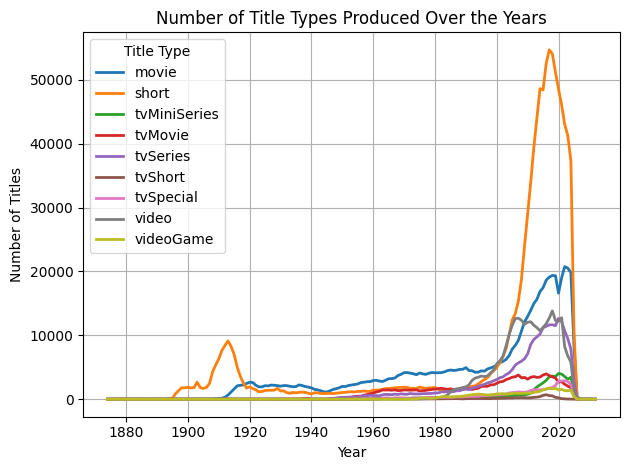

In [ ]:
# Group by year and title type, and count number of titles
title_counts_by_year = df_title_trends.groupby([df_title_trends['startYear'].dt.year, 'titleType']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(14, 6))
title_counts_by_year.plot(kind='line', linewidth=2)
plt.title('Number of Title Types Produced Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.legend(title='Title Type')
plt.tight_layout()
plt.show()

This graph shows how many different types of titles were made each year  like movies, shorts, TV shows, and so on.

The biggest jump is in short films, especially after 2005. Around 2015 to 2019, there were over 50,000 shorts made each year, way more than any other type.

Movies and TV shows also grew over time, but not as fast. Around 2020, everything drops ,most likely because of COVID-19, which paused lots of productions.

 In the last 20 years, short films became super popular, thanks to platforms like YouTube and TikTok, where short videos are quick and easy to make and watch.

### What are the most popular genres over time? 

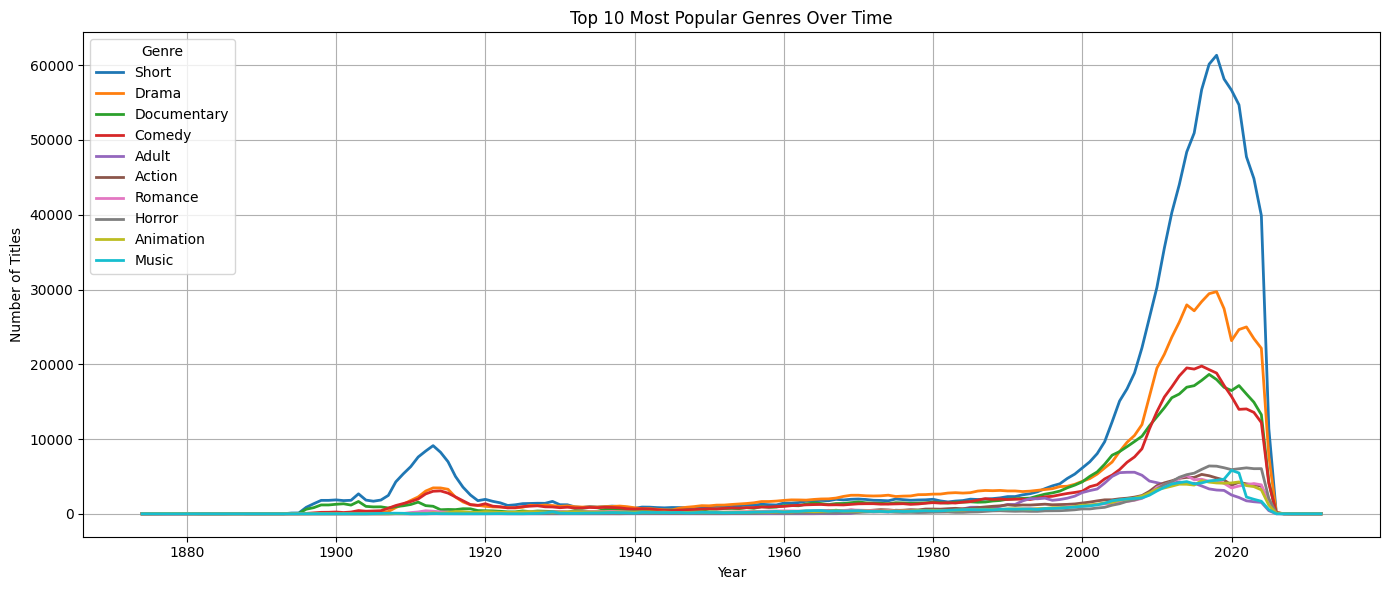

In [ ]:
# Extract year from datetime
df_title_trends['year'] = df_title_trends['startYear'].dt.year

# Explode the genres so each row has a single genre
df_exploded = df_title_trends.copy()
df_exploded['genres'] = df_exploded['genres'].str.split(',')
df_exploded = df_exploded.explode('genres')

# Count the number of titles per year per genre
genre_trends = df_exploded.groupby(['year', 'genres']).size().reset_index(name='count')

# Pivot for plotting
genre_pivot = genre_trends.pivot(index='year', columns='genres', values='count').fillna(0)

# Plot the top 10 most common genres over time
top_genres = genre_pivot.sum().sort_values(ascending=False).head(10).index
genre_pivot[top_genres].plot(figsize=(14, 6), linewidth=2)
plt.title('Top 10 Most Popular Genres Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

Again, Short is the biggest by far after 2005. Drama, Documentary, and Comedy also grew a lot after 2000.

 People are watching and making more quick content, but also more stories with emotions (Drama) and real-life topics (Documentary). It matches how we use streaming today , some content is fast and fun, some deep and meaningful.

### Which decade had the highest number of new titles released?

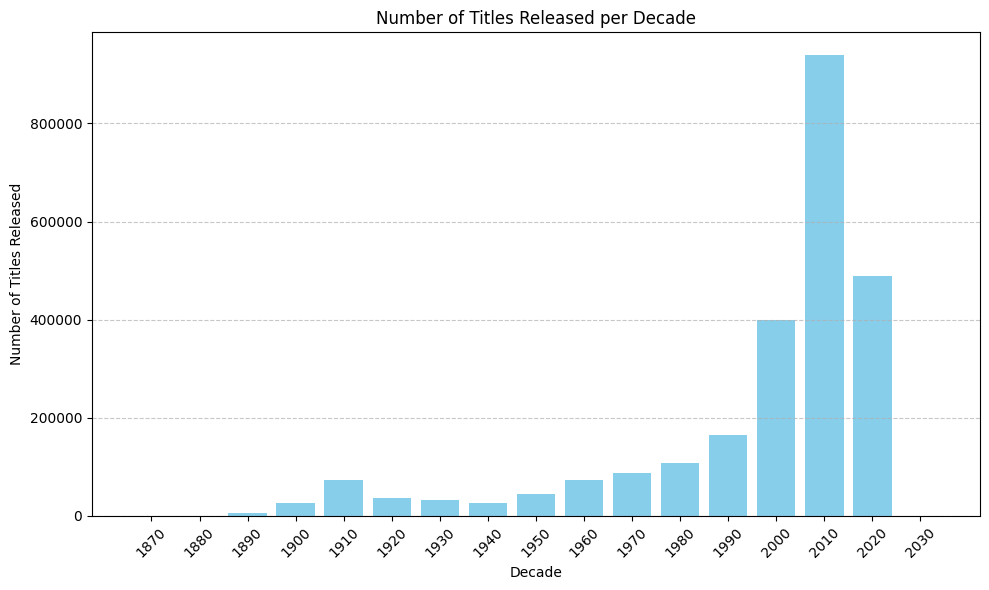

In [ ]:
# Extract the year and calculate the decade
df_title_trends['year'] = df_title_trends['startYear'].dt.year
df_title_trends['decade'] = (df_title_trends['year'] // 10) * 10

# Count titles per decade
decade_counts = df_title_trends['decade'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
plt.bar(decade_counts.index.astype(int).astype(str), decade_counts.values, color='skyblue')
plt.xlabel('Decade')
plt.ylabel('Number of Titles Released')
plt.title('Number of Titles Released per Decade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


For a long time, not many titles were made each decade. But starting in the 1990s, and especially in the 2010s, the number of titles just exploded , almost a million in the 2010s.

Then in the 2020s, there’s a drop. That could be from COVID-19, or maybe things are just changing.

The 2010s were a crazy big decade for movies and shows. More tools, more platforms, more creators. But now, things might be shifting again

## ***Ratings and Popularity***

### how has the number of Votes changed over the years ?

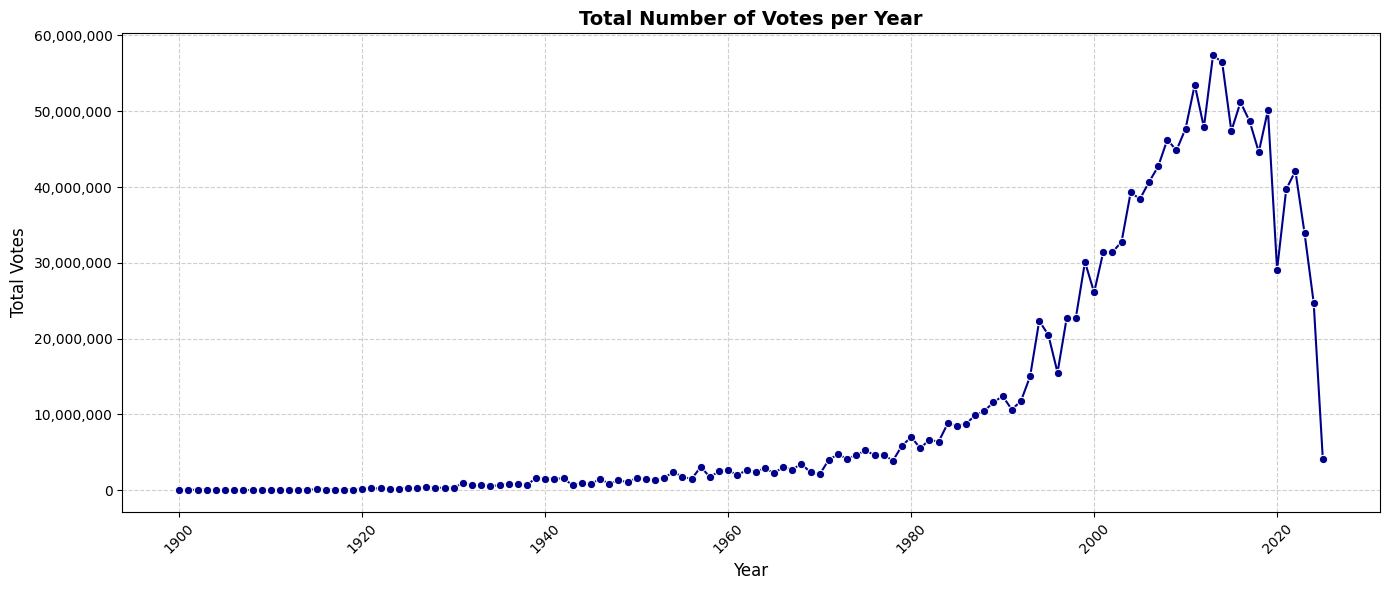

In [ ]:
#  Drop rows with invalid startYear or numVotes
df_votes_analysis = df_votes_analysis.dropna(subset=['startYear', 'numVotes'])

#  Create a separate column for year (don't overwrite startYear!)
df_votes_analysis['year'] = df_votes_analysis['startYear'].dt.year

#  Filter valid years
votes_by_year_df = df_votes_analysis[df_votes_analysis['year'] >= 1900]

#  Group by year and sum votes
votes_by_year = votes_by_year_df.groupby('year')['numVotes'].sum().reset_index()

#  Sort by year
votes_by_year = votes_by_year.sort_values('year')

#  Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=votes_by_year, x='year', y='numVotes', marker='o', color='darkblue')
plt.title('Total Number of Votes per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Votes', fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='x')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Before the internet, most feedback came from critics. But once platforms like IMDb took off, everyday people finally had a voice  and they used it a lot, especially in the 2010s.

### What is the relationship between the number of votes and the average rating?

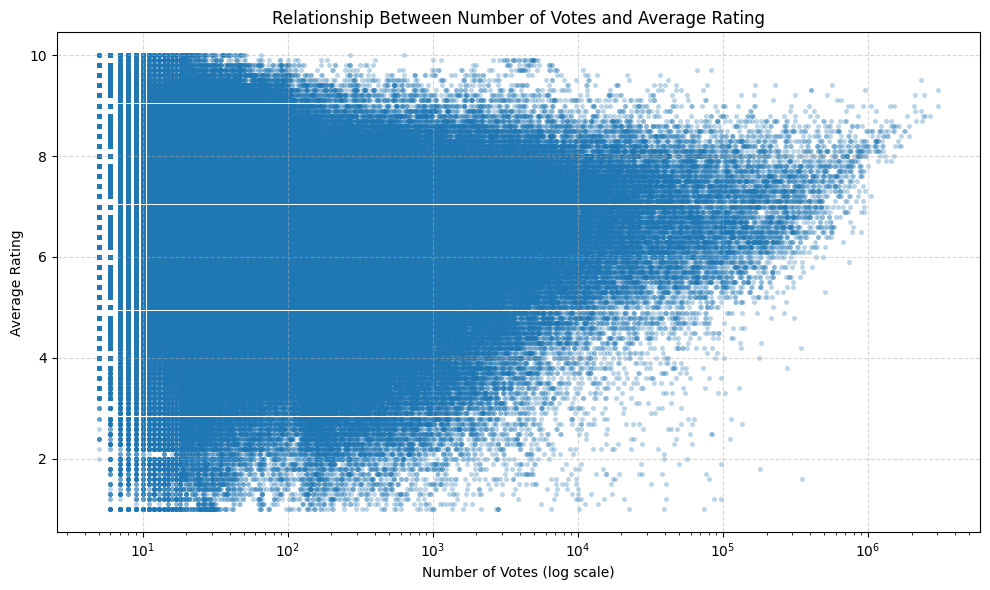

In [ ]:
filtered = df_votes_analysis.dropna(subset=['numVotes', 'averageRating'])  

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered,
    x='numVotes',
    y='averageRating',
    alpha=0.3,
    s=10,
    edgecolor=None
)

plt.xscale('log')  # Log scale to handle skew
plt.xlabel('Number of Votes (log scale)')
plt.ylabel('Average Rating')
plt.title('Relationship Between Number of Votes and Average Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This keeps only the data that has numVotes in a reasonable range, removing those with too few votes to be statistically meaningful. low vote counts usually indicate unreliable or irrelevant titles.

In [ ]:
# Show shape before filtering
print("Shape before removing titles with <10 votes:", rating_analysis.shape)

# Filter: Keep only titles with at least 10 votes
rating_analysis = rating_analysis[rating_analysis['numVotes'] >= 10]

# Reset index after filtering
rating_analysis = rating_analysis.reset_index(drop=True)

# Show shape after filtering
print("Shape after removing titles with <10 votes:", rating_analysis.shape)

Shape before removing titles with <10 votes: (770477, 8)
Shape after removing titles with <10 votes: (657344, 8)


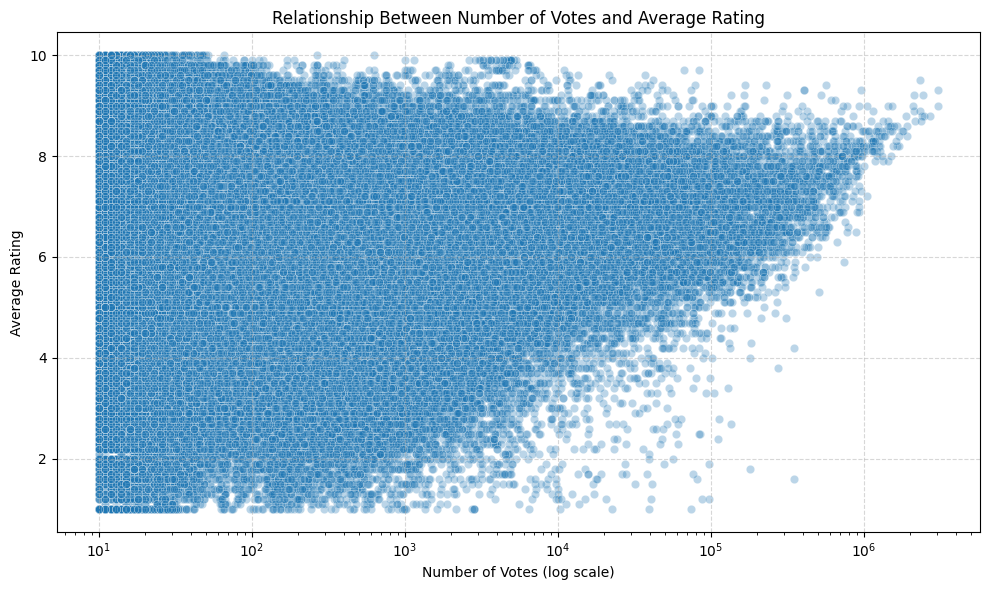

In [ ]:
filtered = rating_analysis.dropna(subset=['numVotes', 'averageRating'])  # Drop rows with NaN values

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered,
    x='numVotes',
    y='averageRating',
    alpha=0.3
)

plt.xscale('log')  # Log scale to handle skew
plt.xlabel('Number of Votes (log scale)')
plt.ylabel('Average Rating')
plt.title('Relationship Between Number of Votes and Average Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The more people vote on a title, the more balanced and realistic the rating becomes. Movies with only a few votes tend to have extreme scores — probably fans or haters only.

### What is the average rating per title type (movies vs TV series vs short, etc.)?

titleType
tvMiniSeries    7.127941
tvSeries        6.819163
tvSpecial       6.803835
videoGame       6.793695
tvShort         6.782258
short           6.686476
tvMovie         6.551871
video           6.550276
movie           6.118087
Name: averageRating, dtype: float64


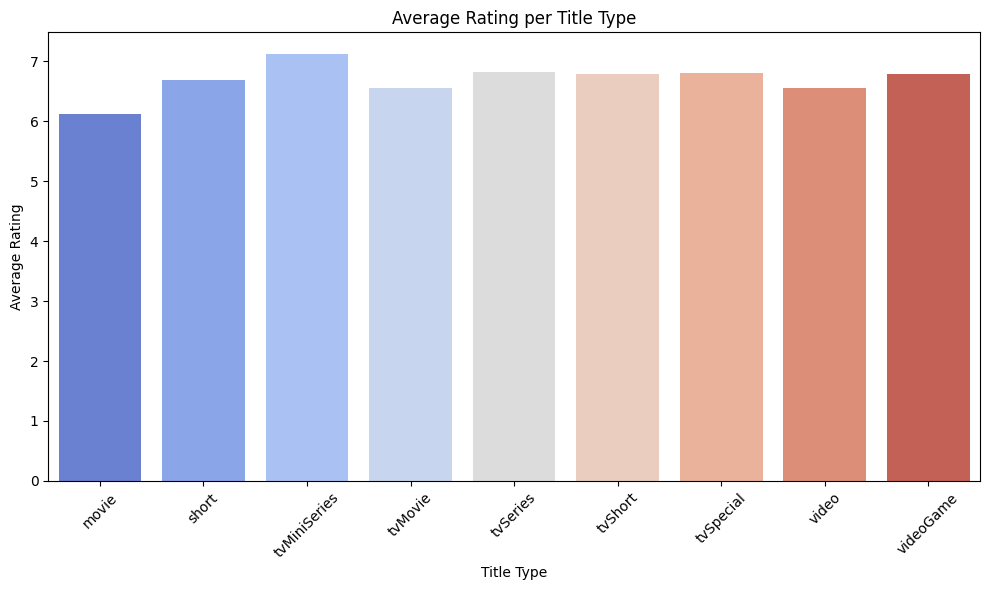

In [ ]:
# Group by titleType and calculate average rating
avg_rating_per_type = rating_analysis.groupby('titleType')['averageRating'].mean().sort_values(ascending=False)

# Display the result
print(avg_rating_per_type)

# Plot it
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_per_type.index, y=avg_rating_per_type.values, palette='coolwarm')
plt.title('Average Rating per Title Type')
plt.ylabel('Average Rating')
plt.xlabel('Title Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Even though movies are the most common title type, they don't score the highest. Mini-series seem to hit the sweet spot for viewers. And other formats like shorts and video games benefit from smaller but more supportive audiences.

### Which genres tend to have the highest average ratings?

genres
Documentary    7.071522
Music          6.994628
Biography      6.983345
History        6.967058
Sport          6.773571
Short          6.690707
Animation      6.591432
War            6.552057
Family         6.531623
Drama          6.456596
Film-Noir      6.451972
Fantasy        6.431447
Musical        6.412973
Reality-TV     6.397095
Adventure      6.389356
Talk-Show      6.342709
Romance        6.302278
Comedy         6.295469
News           6.273406
Crime          6.260233
Mystery        6.246438
Adult          6.237229
Game-Show      6.201568
Action         6.170724
Sci-Fi         6.088728
Western        5.994855
Thriller       5.850843
Horror         5.511116
Name: averageRating, dtype: float64


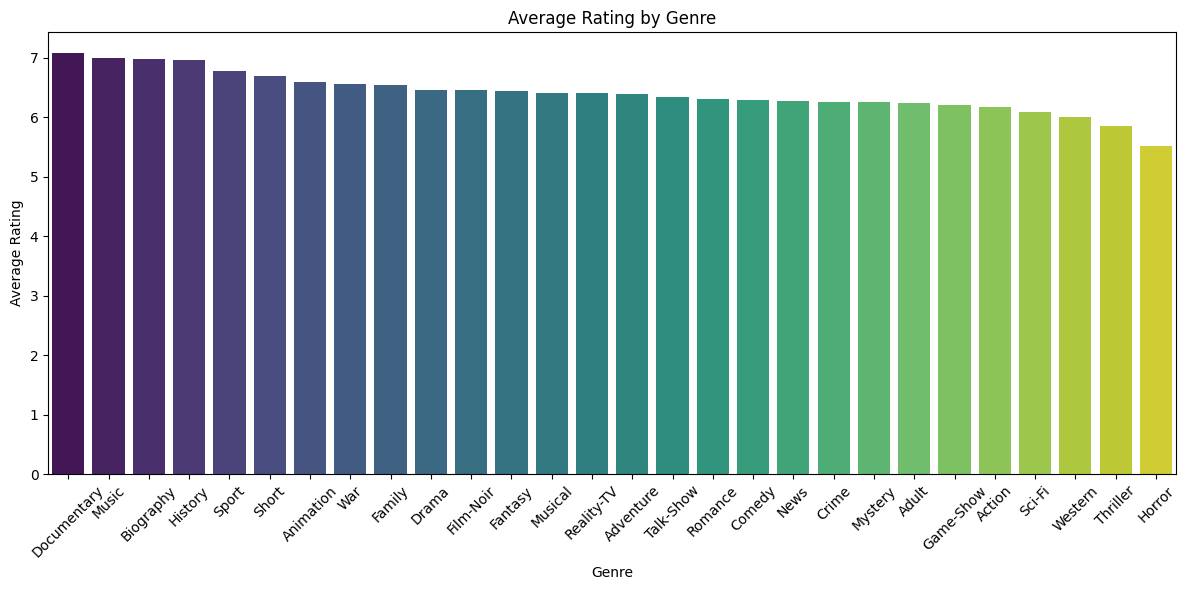

In [ ]:
#  Drop rows with missing genres or averageRating
genre_ratings = rating_analysis.dropna(subset=['genres', 'averageRating'])

# Split multiple genres and explode into separate rows
genre_ratings['genres'] = genre_ratings['genres'].str.split(',')
genre_ratings = genre_ratings.explode('genres')

#  Clean up genre whitespace 
genre_ratings['genres'] = genre_ratings['genres'].str.strip()

#  Group by genre and compute average rating
avg_rating_by_genre = genre_ratings.groupby('genres')['averageRating'].mean().sort_values(ascending=False)

#  Print results
print(avg_rating_by_genre)

#  Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_rating_by_genre.index, y=avg_rating_by_genre.values, palette='viridis')
plt.title('Average Rating by Genre')
plt.ylabel('Average Rating')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Has the average rating of titles increased or decreased over the years?

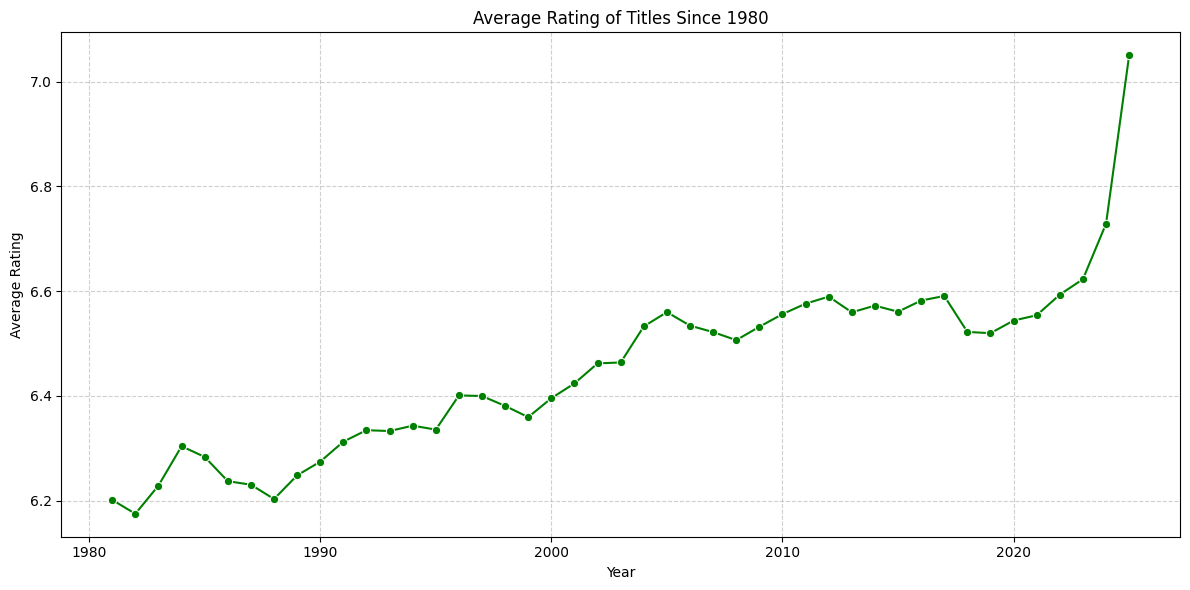

In [ ]:
#  Ensure startYear is in datetime format
if not pd.api.types.is_datetime64_any_dtype(rating_analysis['startYear']):
    rating_analysis['startYear'] = pd.to_datetime(rating_analysis['startYear'], errors='coerce')

#  Drop rows with missing data
rating_analysis = rating_analysis.dropna(subset=['startYear', 'averageRating'])

#  Extract the year component
rating_analysis['year'] = rating_analysis['startYear'].dt.year

#  Filter only years after 1980
filtered_data = rating_analysis[rating_analysis['year'] > 1980]

#  Group by year and calculate average rating
avg_rating_per_year = filtered_data.groupby('year')['averageRating'].mean()

# Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_rating_per_year.index, y=avg_rating_per_year.values, marker='o', color='green')
plt.title('Average Rating of Titles Since 1980')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


like we said before , film critics were the only ones who were allowed to vote , so they didnt give movies high rating .
Over time, the average rating has slowly gone up  but the big rise after 2020 is probably not just about quality. It's likely affected by who’s rating the content and how many people are doing it. Newer titles might not be reaching a wide audience, but the ones who do watch  really like them.

### What is the distribution of number of votes? Are there a few titles with many votes and many with very few?

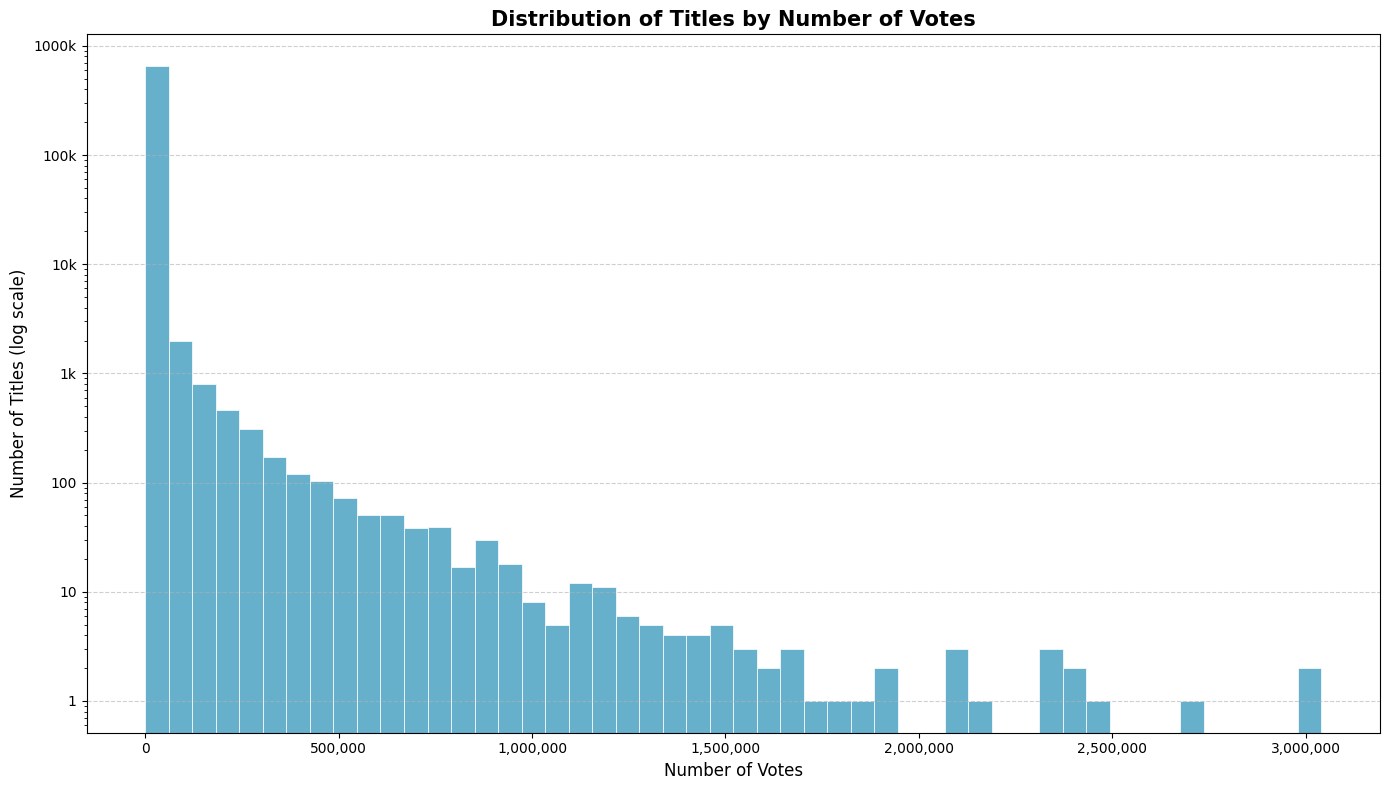

In [ ]:
plt.figure(figsize=(14, 8))  

# Plot histogram
counts, bins, patches = plt.hist(
    rating_analysis['numVotes'],
    bins=50,
    color='#4BA3C3',
    edgecolor='white',
    linewidth=0.6,
    alpha=0.85
)

# Format y-axis labels in 'k' format
def y_format_func(value, tick_number):
    if value >= 1000:
        return f'{int(value / 1000)}k'
    else:
        return f'{int(value)}'

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(y_format_func))
plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))

# Format x-axis to show regular numbers with commas
def x_format_func(value, tick_number):
    return f'{int(value):,}'

plt.gca().xaxis.set_major_formatter(FuncFormatter(x_format_func))

# Labels and title
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Number of Titles (log scale)', fontsize=12)
plt.title('Distribution of Titles by Number of Votes', fontsize=15, fontweight='bold')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Which title types tend to get more votes on average?

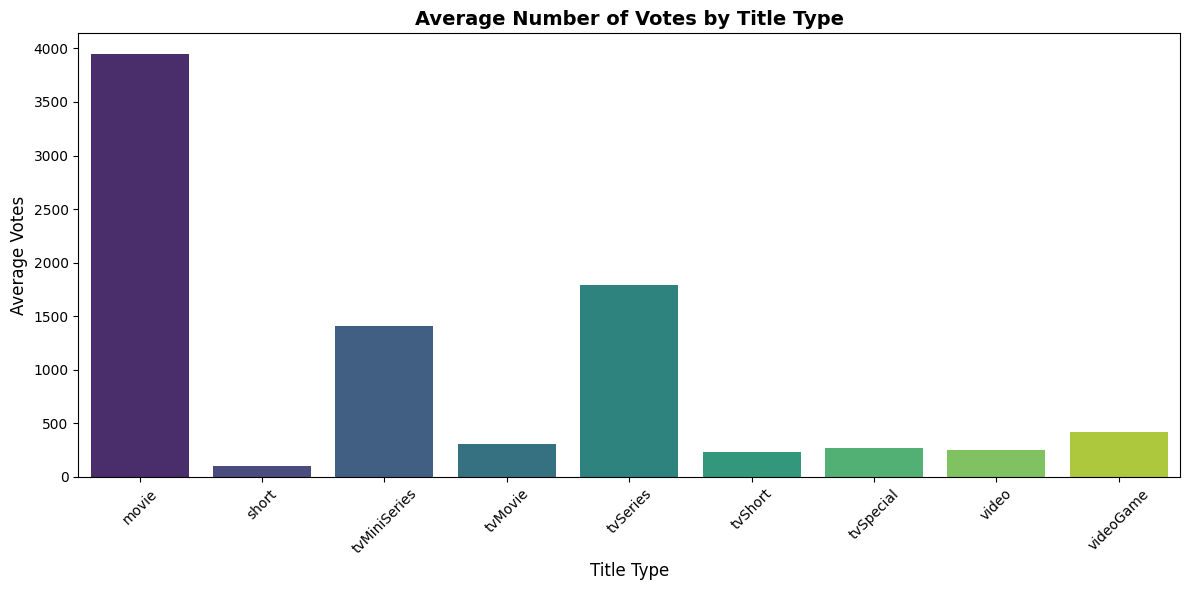

In [ ]:
# Group by titleType and calculate average number of votes
avg_votes_by_type = rating_analysis.groupby('titleType')['numVotes'].mean().sort_values(ascending=False).reset_index()

# Plot the result
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_votes_by_type, x='titleType', y='numVotes', palette='viridis')
plt.title('Average Number of Votes by Title Type', fontsize=14, fontweight='bold')
plt.xlabel('Title Type', fontsize=12)
plt.ylabel('Average Votes', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Movies dominate in visibility and voting, while other title types  like shorts or specials  stay in the background. So when comparing ratings across types, we should remember that a high average rating doesn’t always mean high popularity  it might just mean fewer people voted.

### Ratings Distribution of KnownForTitles

In [ ]:
# Drop missing and explode knownForTitles
known = names_df.dropna().copy()
known["knownForTitles"] = known["knownForTitles"].str.split(",")
known_titles = pd.Series([t for sublist in known["knownForTitles"] for t in sublist], name="tconst")

# Deduplicate and join
known_titles = known_titles.drop_duplicates().to_frame()
known_ratings = known_titles.merge(ratings_df, on="tconst", how="inner")

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(known_ratings["averageRating"], bins=30, kde=True)
plt.title("Ratings Distribution of KnownForTitles")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## ***Genre Insights***

### generes What are the most popular genres (by count of titles)?

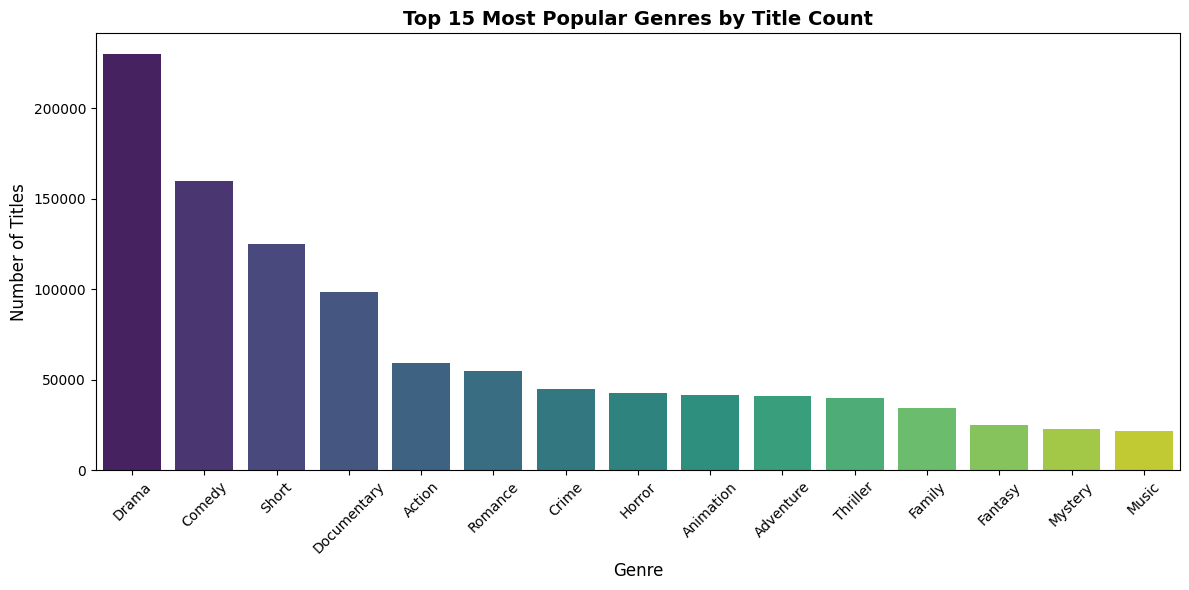

In [ ]:
# Step 1: Drop missing genre values
df_genres = rating_analysis.dropna(subset=['genres'])

# Step 2: Split genres and flatten the list
df_genres['genres'] = df_genres['genres'].str.split(',')
all_genres = df_genres['genres'].explode().str.strip()

# Step 3: Count genre occurrences
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False).reset_index()
genre_counts.columns = ['Genre', 'Title Count']

# Step 4: Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_counts.head(15), x='Genre', y='Title Count', palette='viridis')
plt.title('Top 15 Most Popular Genres by Title Count', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')  # Ensure plain formatting
plt.tight_layout()
plt.show()

### What are the most common genre combinations?

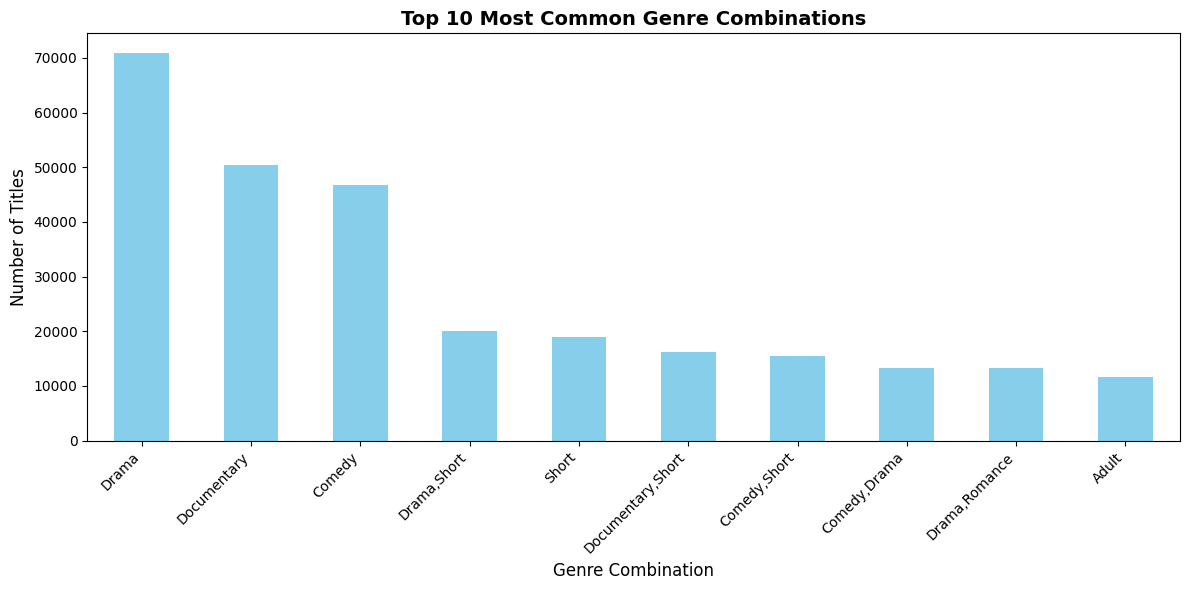

In [ ]:
# Drop missing genres
genre_combos = rating_analysis['genres'].dropna()

# Count occurrences of each unique genre combination
genre_combo_counts = genre_combos.value_counts().head(10)

# Plot the top 10 most common genre combinations
plt.figure(figsize=(12, 6))
genre_combo_counts.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Common Genre Combinations', fontsize=14, fontweight='bold')
plt.xlabel('Genre Combination', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Are certain genre combinations associated with higher ratings?

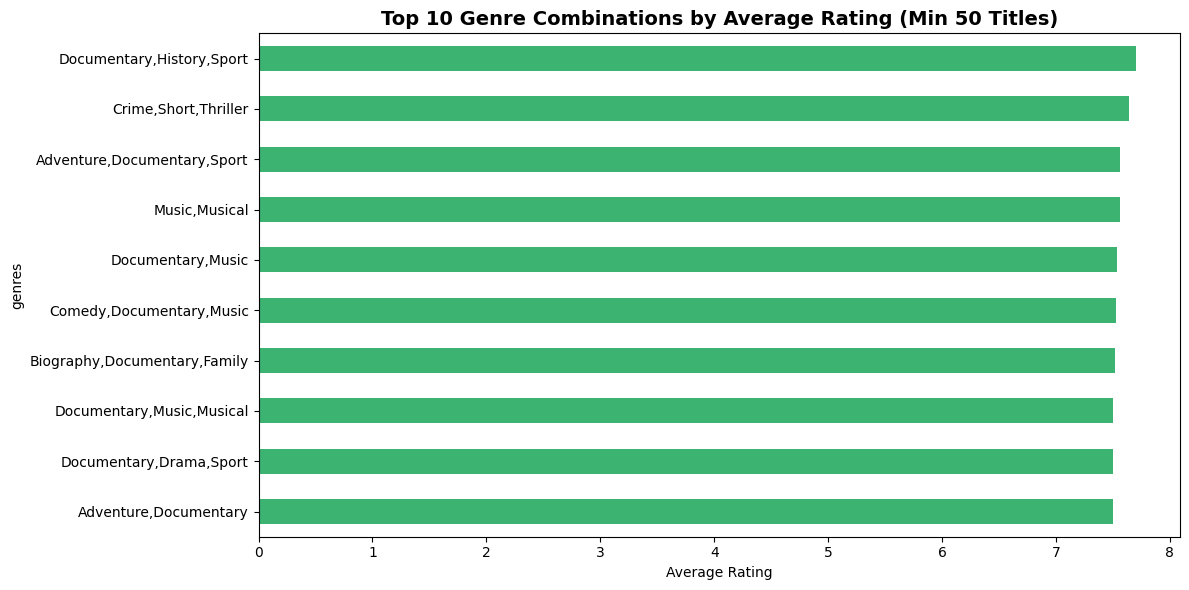

In [ ]:
# Drop rows with missing values in 'genres' or 'averageRating'
valid_ratings = rating_analysis.dropna(subset=['genres', 'averageRating'])

# Group by genre combination and calculate the mean rating and count
genre_rating_stats = valid_ratings.groupby('genres')['averageRating'].agg(['mean', 'count'])

# Filter to only include genre combinations with a reasonable number of titles 
popular_genre_combos = genre_rating_stats[genre_rating_stats['count'] >= 50]

# Sort by mean rating and get top 10
top_genre_combos = popular_genre_combos.sort_values('mean', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
top_genre_combos['mean'].plot(kind='barh', color='mediumseagreen')
plt.xlabel('Average Rating')
plt.title('Top 10 Genre Combinations by Average Rating (Min 50 Titles)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

If you're aiming for high ratings, combining Documentary with meaningful or engaging genres (like Sport, Music, or History) is a strong move. These genres clearly resonate with audiences, and the data backs it up.

## ***Regions***

### Top 20 Regions by Number of Localized Titles

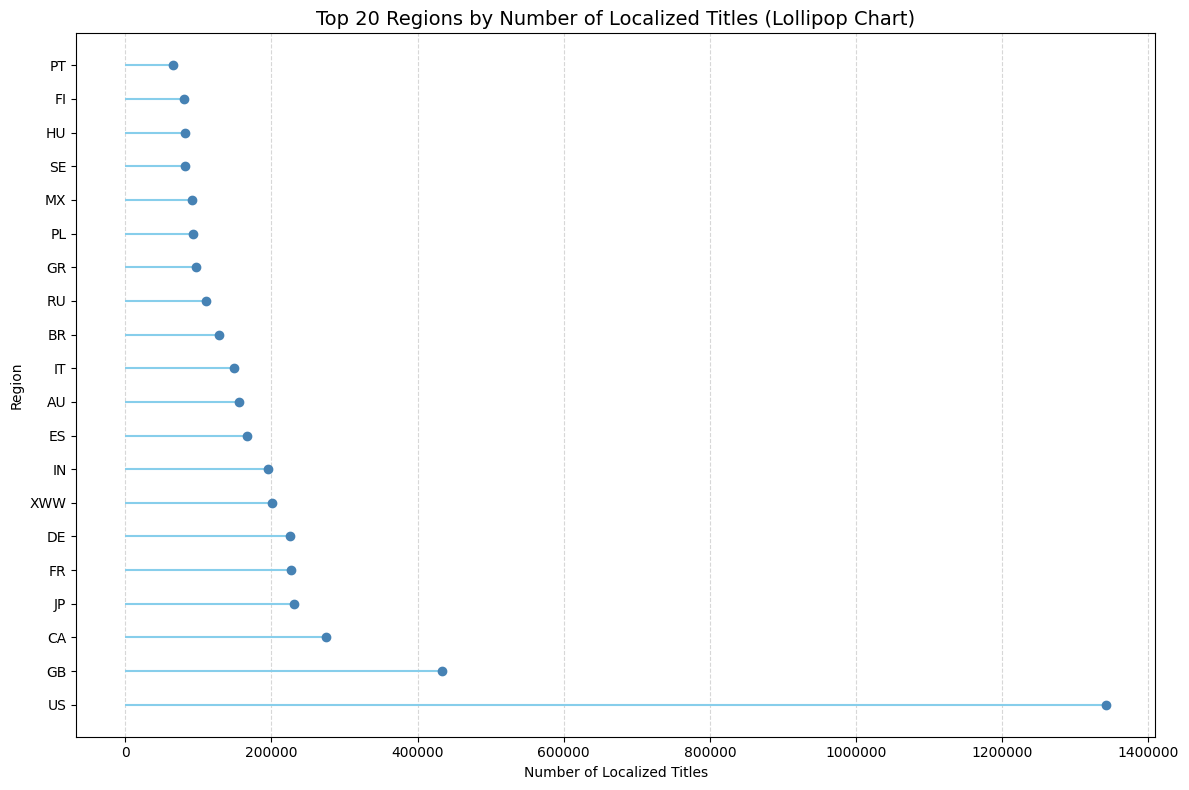

In [ ]:
# Manual data
regions = [
    'US', 'GB', 'CA', 'JP', 'FR', 'DE', 'XWW', 'IN', 'ES', 'AU',
    'IT', 'BR', 'RU', 'GR', 'PL', 'MX', 'SE', 'HU', 'FI', 'PT'
]
counts = [
    1341928, 433727, 274210, 230302, 227018, 225497, 200105, 195858, 167066, 155372,
    148740, 127857, 109989, 97225, 92303, 91027, 81668, 81075, 80932, 65938
]

# Plotting
plt.figure(figsize=(12, 8))
plt.hlines(y=regions, xmin=0, xmax=counts, color='skyblue')
plt.plot(counts, regions, "o", color='steelblue')

# Labels
plt.title("Top 20 Regions by Number of Localized Titles (Lollipop Chart)", fontsize=14)
plt.xlabel("Number of Localized Titles")
plt.ylabel("Region")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

## ***Cast & Crew***

### Which directors appear most frequently?

In [ ]:
# Filter out rows in basics where titleType == 'tvEpisode'
non_tv_episodes = basics_df[basics_df['titleType'] != 'tvEpisode']

# Keep only ratings for titles that are NOT tvEpisodes
filtered_ratings = ratings_df[ratings_df['tconst'].isin(non_tv_episodes['tconst'])]

# Save the cleaned ratings file (optional)
filtered_ratings.to_csv('title.ratings.filtered.tsv', sep='\t', index=False)

# Display result summary
print(f"Original ratings count: {len(ratings_df)}")
print(f"Filtered ratings count: {len(filtered_ratings)}")

Original ratings count: 1565832
Filtered ratings count: 770477


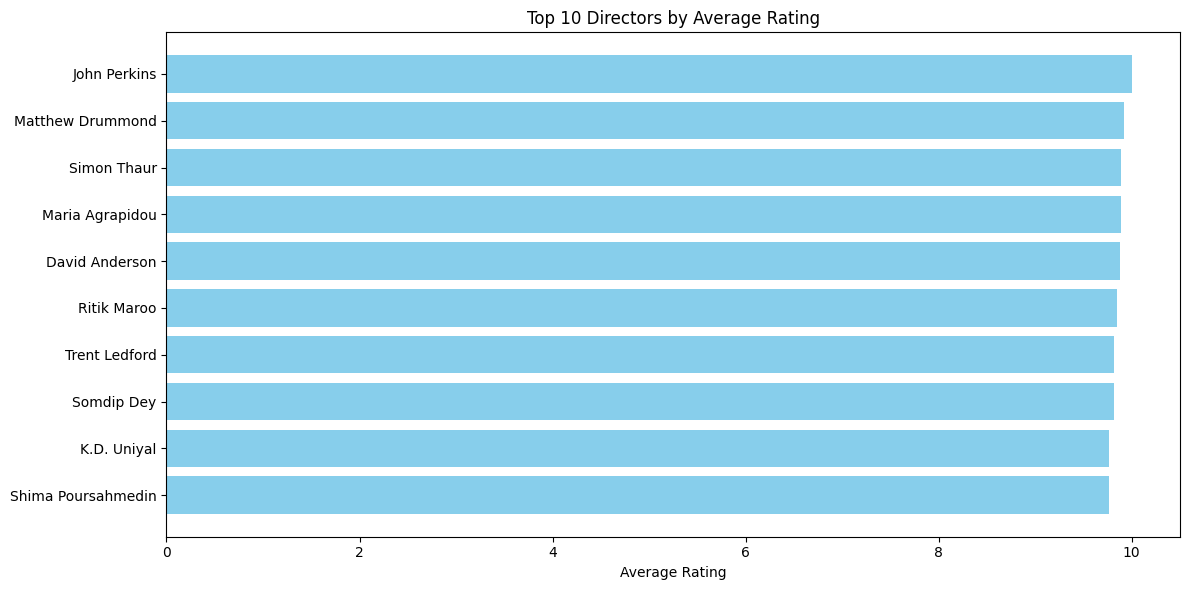

In [ ]:
# Load necessary datasets
title_ratings_df = filtered_ratings

# Explode director IDs
exploded_df = crew_df.copy()
exploded_df['tconst'] = crew_df['tconst']
exploded_df = exploded_df.assign(directors=crew_df['directors'].str.split(',')).explode('directors')

# Merge with ratings
exploded_df = exploded_df.merge(title_ratings_df, on='tconst', how='left')

# Drop rows with missing ratings
exploded_df = exploded_df.dropna(subset=['averageRating'])

# Group by director and compute average rating and count
director_avg_rating = exploded_df.groupby('directors').agg(
    avg_rating=('averageRating', 'mean'),
    movie_count=('tconst', 'count')
).reset_index()

# Filter directors with at least 5 titles for better reliability (optional)
director_avg_rating = director_avg_rating[director_avg_rating['movie_count'] >= 5]

# Get director names
director_avg_rating = director_avg_rating.merge(names_df[['nconst', 'primaryName']], left_on='directors', right_on='nconst', how='left')

# Get top 10 directors by average rating
top_rated_directors = director_avg_rating.sort_values(by='avg_rating', ascending=False).head(10)

# Drop rows with missing director names
top_rated_directors = top_rated_directors.dropna(subset=['primaryName'])

# Plotting
plt.figure(figsize=(12, 6))
plt.barh(top_rated_directors['primaryName'], top_rated_directors['avg_rating'], color='skyblue')
plt.xlabel('Average Rating')
plt.title('Top 10 Directors by Average Rating')
plt.gca().invert_yaxis()  # Highest rating at top
plt.tight_layout()
plt.show()

### Show top 10 most frequent directors by name

In [ ]:
# Split multiple director IDs into separate rows
exploded_directors = crew_df['directors'].str.split(',').explode()

# Count occurrences of each director ID
director_counts = exploded_directors.value_counts().reset_index()
director_counts.columns = ['nconst', 'count']

# Merge with name.basics to get director names
director_counts_named = pd.merge(director_counts, names_df[['nconst', 'primaryName']], on='nconst', how='left')

# Show top 10 most frequent directors by name
top_directors = director_counts_named[['primaryName', 'count']].head(10)
print(top_directors)

        primaryName  count
0    Johnny Manahan  13154
1   Saibal Banerjee  12931
2     Nivedita Basu  12368
3      Bert De Leon  10365
4      Anil v Kumar   8984
5     Santosh Bhatt   8495
6     Danie Joubert   8377
7   Conrado Lumabas   8024
8       Duma Ndlovu   7986
9  Silvia Abravanel   7437


### Top 10 Actors by Genre Diversity

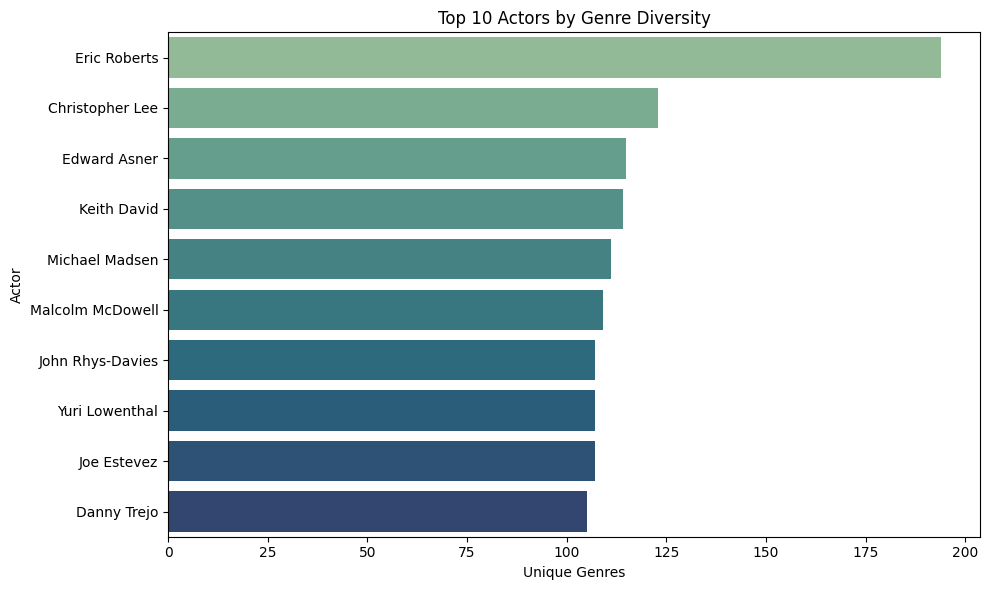

In [ ]:
basics_working  = basics_df.copy()  
basics_working ["genres"] = basics_working ["genres"].fillna("").astype(str).str.split(",")
basics_working .loc[basics_df["genres"].apply(lambda x: x == ['']), "genres"] = None

# Create genre dictionary for quick lookup
genre_dict = dict(zip(basics_df["tconst"], basics_df["genres"]))

# --- Create a working copy of principals_df ---
principals_working = principals_df[principals_df["category"].isin(["actor", "actress"])].copy()

# Map genres to each title
principals_working["genres"] = principals_working["tconst"].map(genre_dict)

# Drop rows without genre info
principals_working = principals_working.dropna(subset=["genres"])

# Explode genres: one row per genre
principals_exploded = principals_working.explode("genres")

# Group by actor and aggregate unique genres as set
actor_genres = principals_exploded.groupby("nconst")["genres"].agg(set).reset_index()

# Count unique genres per actor
actor_genres["genre_count"] = actor_genres["genres"].apply(len)

# Merge actor names
actor_genres = actor_genres.merge(names_df, on="nconst", how="left")

# Select top 10 actors by genre diversity
top_actors = actor_genres.sort_values("genre_count", ascending=False).head(10)

# --- Plotting ---
plt.figure(figsize=(10, 6))
sns.barplot(data=top_actors, x="genre_count", y="primaryName", palette="crest")
plt.title("Top 10 Actors by Genre Diversity")
plt.xlabel("Unique Genres")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

### Number of Projects vs. Average Rating of Directors

Correlation between number of projects and average rating: 0.0309
Regression Coefficient (Slope): 0.0020
Regression Intercept: 6.7834
R-squared: 0.0010
Adjusted R-squared: 0.0010
Standard Error of Residuals: 1.3595
P-value: 0.000000
Statistical Significance: Yes (α = 0.05)


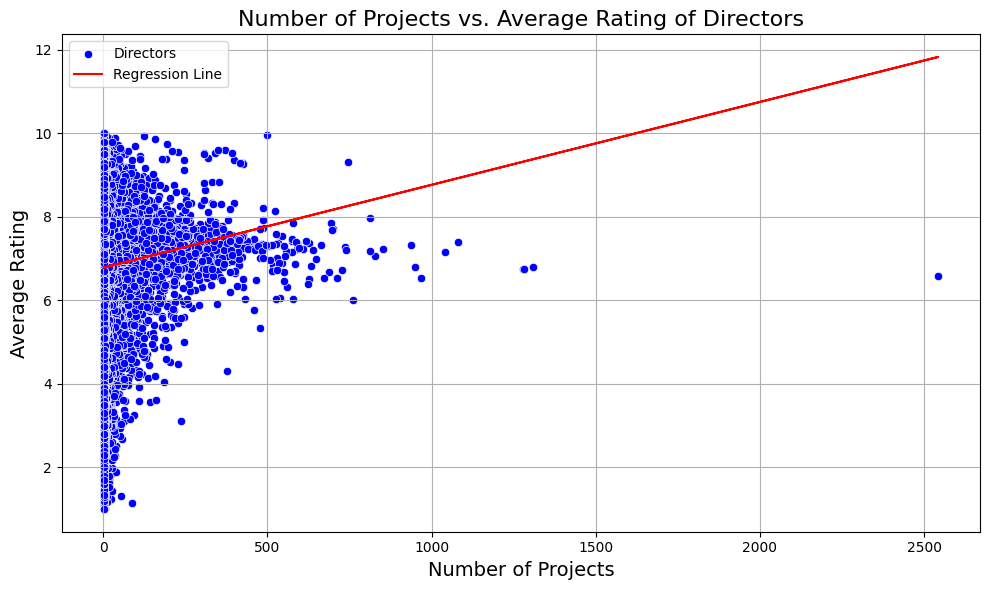

In [ ]:

#  Clean Ratings 
ratings_df_clean = ratings_df[['tconst', 'averageRating', 'numVotes']].copy()

#  Prepare Directors 
# Keep only tconst and directors
crew_df_clean = crew_df[['tconst', 'directors']].dropna()

# Split multiple directors and explode into one row per director
crew_df_clean['directors'] = crew_df_clean['directors'].str.split(',')
directors_df = crew_df_clean.explode('directors')


#  Merge with Ratings 
director_ratings = pd.merge(directors_df, ratings_df_clean, on='tconst', how='inner')

#  Group and Aggregate 
director_stats = director_ratings.groupby('directors').agg(
    num_titles=('tconst', 'count'),
    avg_rating=('averageRating', 'mean'),
    total_votes=('numVotes', 'sum')
).reset_index()

#  Add Director Names 
director_stats = director_stats.merge(
    names_df[['nconst', 'primaryName']],
    left_on='directors',
    right_on='nconst',
    how='left'
)

#  Correlation 
correlation = director_stats['num_titles'].corr(director_stats['avg_rating'])
print(f"Correlation between number of projects and average rating: {correlation:.4f}")

# Linear Regression 
X = director_stats[['num_titles']].values
y = director_stats['avg_rating'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred
r_squared = model.score(X, y)
n = len(y)
p = 1
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f"Regression Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Regression Intercept: {model.intercept_:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared:.4f}")
print(f"Standard Error of Residuals: {np.std(residuals):.4f}")

# P-value
slope, intercept, r_value, p_value, std_err = stats.linregress(
    director_stats['num_titles'], 
    director_stats['avg_rating']
)
print(f"P-value: {p_value:.6f}")
print(f"Statistical Significance: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")

# Plot 
plt.figure(figsize=(10, 6))
sns.scatterplot(x='num_titles', y='avg_rating', data=director_stats, color='blue', label='Directors')
plt.plot(director_stats['num_titles'], y_pred, color='red', label='Regression Line')

plt.title('Number of Projects vs. Average Rating of Directors', fontsize=16)
plt.xlabel('Number of Projects', fontsize=14)
plt.ylabel('Average Rating', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Although the red trend line suggests that directors with more projects have higher average ratings, the actual data shows no clear link between number of projects and quality. Most directors have only made a few films, and their ratings vary widely — from very low to very high. The upward trend is skewed by a few very active directors with consistent performance.

### Director Productivity

In [ ]:
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


#  DIRECTOR STATISTICS 
# Group by director and calculate comprehensive stats
director_stats = director_ratings.groupby('directors').agg(
    num_titles=('tconst', 'count'),
    avg_rating=('averageRating', 'mean'),
    median_rating=('averageRating', 'median'),
    std_rating=('averageRating', 'std'),
    total_votes=('numVotes', 'sum'),
    avg_votes=('numVotes', 'mean'),
    max_rating=('averageRating', 'max'),
    min_rating=('averageRating', 'min')
).reset_index()

# Fill NaN standard deviations (directors with only 1 title)
director_stats['std_rating'] = director_stats['std_rating'].fillna(0)

# Merge with names to get director's name
director_stats = director_stats.merge(
    names_df[['nconst', 'primaryName', 'primaryProfession', 'knownForTitles']], 
    left_on='directors', 
    right_on='nconst', 
    how='left'
)

# Statistical significance test
slope, intercept, r_value, p_value, std_err = stats.linregress(
    director_stats['num_titles'], 
    director_stats['avg_rating']
)

# TOP DIRECTORS ANALYSIS 
# Most prolific directors
print("\nMost Prolific Directors (10+ titles):")
top_prolific = director_stats[director_stats['num_titles'] >= 10].nlargest(150, 'num_titles')
for _, row in top_prolific.iterrows():
    name = row['primaryName'] if pd.notna(row['primaryName']) else 'Unknown'
    print(f"  {name}: {row['num_titles']} titles, avg rating: {row['avg_rating']:.2f}")

# Highest rated directors (with 5+ titles)
print("\nHighest Rated Directors (5+ titles):")
top_rated = director_stats[director_stats['num_titles'] >= 5].nlargest(150, 'avg_rating')
for _, row in top_rated.iterrows():
    name = row['primaryName'] if pd.notna(row['primaryName']) else 'Unknown'
    print(f"  {name}: {row['avg_rating']:.2f} avg rating, {row['num_titles']} titles")


# SUMMARY STATISTICS 
print("SUMMARY STATISTICS")
print(f"{'='*50}")
print(f"Total directors analyzed: {len(director_stats)}")
print(f"Average projects per director: {director_stats['num_titles'].mean():.2f}")
print(f"Median projects per director: {director_stats['num_titles'].median():.2f}")
print(f"Average rating across all directors: {director_stats['avg_rating'].mean():.3f}")
print(f"Standard deviation of average ratings: {director_stats['avg_rating'].std():.3f}")

# Quality vs Quantity insights
high_volume = director_stats[director_stats['num_titles'] >= director_stats['num_titles'].quantile(0.8)]
low_volume = director_stats[director_stats['num_titles'] <= director_stats['num_titles'].quantile(0.2)]

print(f"\nHigh-volume directors (top 20%): avg rating = {high_volume['avg_rating'].mean():.3f}")
print(f"Low-volume directors (bottom 20%): avg rating = {low_volume['avg_rating'].mean():.3f}")



Most Prolific Directors (10+ titles):
  Chuck O'Neil: 2543 titles, avg rating: 6.58
  Doug Walker: 1308 titles, avg rating: 6.81
  William Hanna: 1282 titles, avg rating: 6.75
  Joseph Barbera: 1277 titles, avg rating: 6.76
  James Burrows: 1079 titles, avg rating: 7.40
  Russell Norman: 1041 titles, avg rating: 7.15
  Ray Patterson: 969 titles, avg rating: 6.54
  Dave Diomedi: 949 titles, avg rating: 6.79
  Michael Simon: 937 titles, avg rating: 7.32
  Tyler Perry: 851 titles, avg rating: 7.24
  James Rolfe: 828 titles, avg rating: 7.06
  Michael Pearlman: 812 titles, avg rating: 7.98
  Luke Lerdwichagul: 811 titles, avg rating: 7.18
  David Paul Meyer: 762 titles, avg rating: 6.00
  Leonardo Thimo: 745 titles, avg rating: 9.32
  Mark W. Roden: 739 titles, avg rating: 7.20
  Hayato Date: 736 titles, avg rating: 7.28
  Brian Smith: 727 titles, avg rating: 6.73
  Kevin Dunn: 713 titles, avg rating: 6.53
  Daisuke Nishio: 701 titles, avg rating: 7.71
  Mr. GVSM: 695 titles, avg rating: 

### Writer Productivity


Most Prolific Writers (10+ titles):
  Lizz Winstead: 3911 titles, avg rating: 6.29
  Madeleine Smithberg: 3902 titles, avg rating: 6.29
  Jon Stewart: 3811 titles, avg rating: 6.73
  Dick Wolf: 2617 titles, avg rating: 7.83
  Stephen Colbert: 2491 titles, avg rating: 6.61
  Steve Bodow: 2461 titles, avg rating: 6.52
  Geoff McQueen: 2439 titles, avg rating: 7.48
  J.R. Havlan: 2430 titles, avg rating: 6.33
  Daniel Radosh: 2265 titles, avg rating: 6.41
  Eric Drysdale: 2110 titles, avg rating: 6.80
  Zhubin Parang: 2042 titles, avg rating: 6.39
  Ben Karlin: 1932 titles, avg rating: 6.88
  Shotaro Ishinomori: 1888 titles, avg rating: 7.34
  Lauren Sarver Means: 1793 titles, avg rating: 6.35
  Jason Ross: 1732 titles, avg rating: 6.48
  Tim Carvell: 1717 titles, avg rating: 6.67
  Matt Koff: 1705 titles, avg rating: 6.30
  Norman Lear: 1675 titles, avg rating: 7.58
  Dan Amira: 1628 titles, avg rating: 6.26
  Dan McCoy: 1586 titles, avg rating: 6.44
  Glenn Eichler: 1565 titles, avg ra

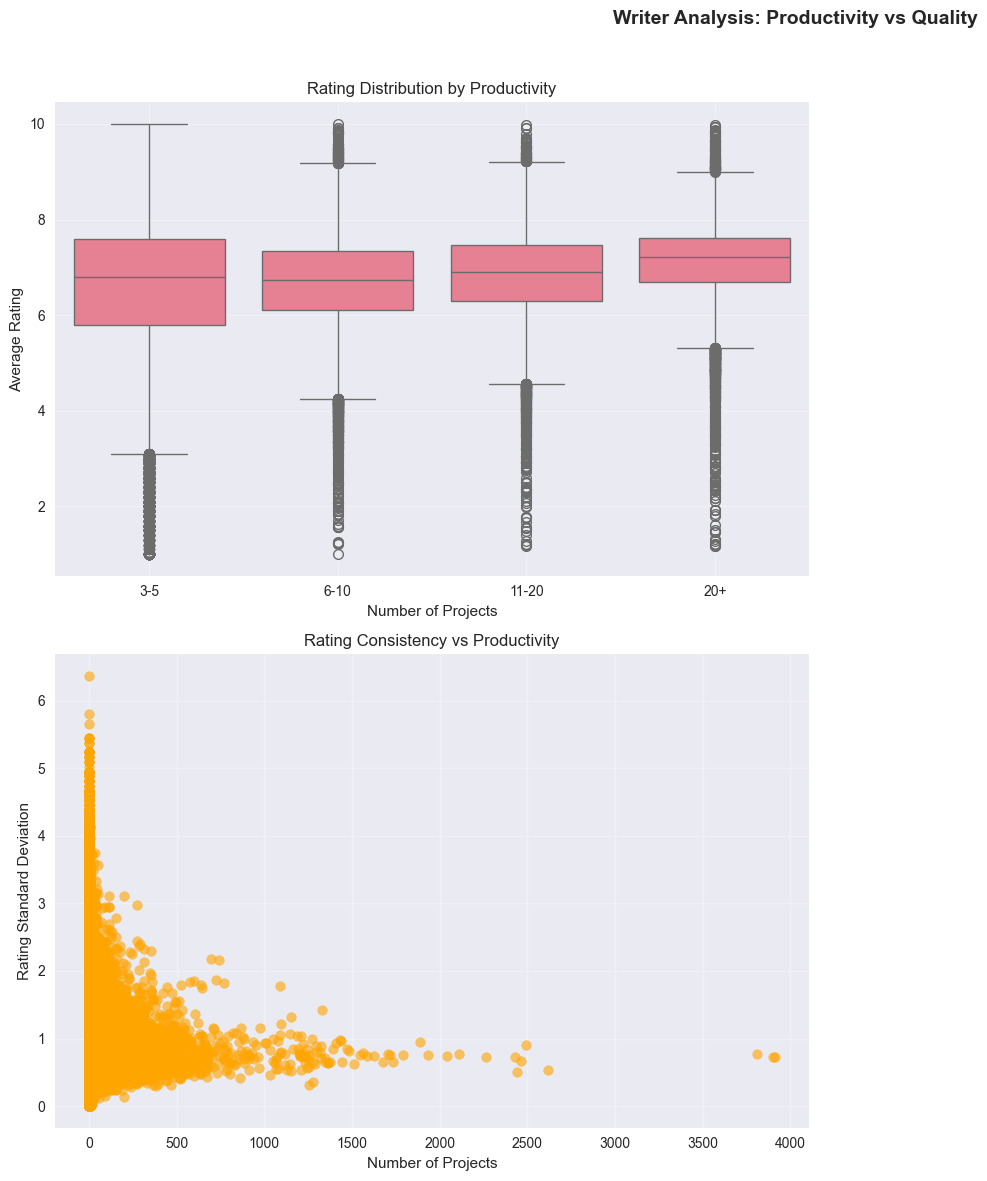

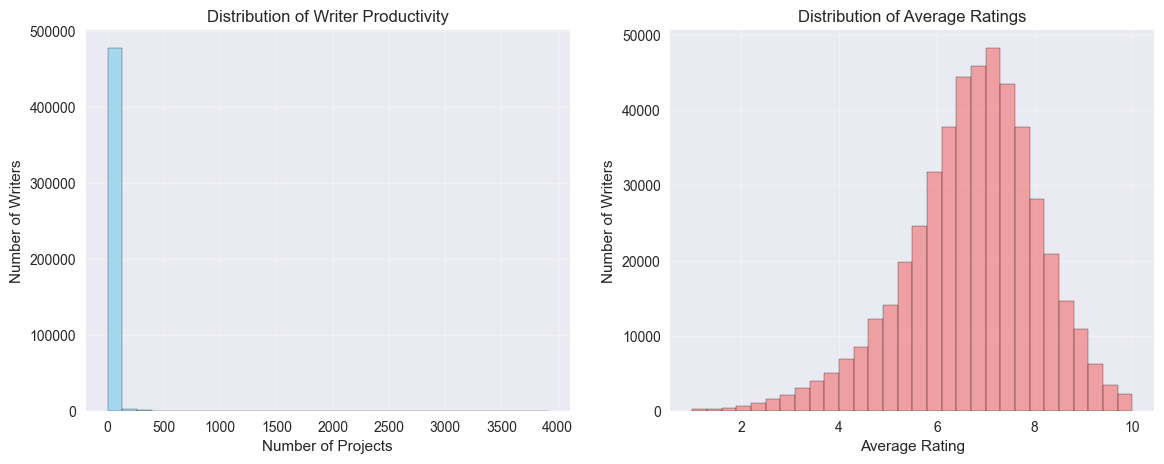

SUMMARY STATISTICS
Total writers analyzed: 480283
Average projects per writer: 6.75
Median projects per writer: 1.00
Average rating across all writers: 6.691
Standard deviation of average ratings: 1.349

High-volume writers (top 20%): avg rating = 6.801
Low-volume writers (bottom 20%): avg rating = 6.669


In [ ]:
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



# WRITER STATISTICS 
writer_stats = writer_ratings.groupby('writers').agg(
    num_titles=('tconst', 'count'),
    avg_rating=('averageRating', 'mean'),
    median_rating=('averageRating', 'median'),
    std_rating=('averageRating', 'std'),
    total_votes=('numVotes', 'sum'),
    avg_votes=('numVotes', 'mean'),
    max_rating=('averageRating', 'max'),
    min_rating=('averageRating', 'min')
).reset_index()

writer_stats['std_rating'] = writer_stats['std_rating'].fillna(0)

# Merge with names to get writer's name
writer_stats = writer_stats.merge(
    names_df[['nconst', 'primaryName', 'primaryProfession', 'knownForTitles']], 
    left_on='writers', 
    right_on='nconst', 
    how='left'
)

# Statistical significance test
slope, intercept, r_value, p_value, std_err = stats.linregress(
    writer_stats['num_titles'], 
    writer_stats['avg_rating']
)

#  TOP WRITERS ANALYSIS 
print("\nMost Prolific Writers (10+ titles):")
top_prolific = writer_stats[writer_stats['num_titles'] >= 10].nlargest(50, 'num_titles')
for _, row in top_prolific.iterrows():
    name = row['primaryName'] if pd.notna(row['primaryName']) else 'Unknown'
    print(f"  {name}: {row['num_titles']} titles, avg rating: {row['avg_rating']:.2f}")

print("\nHighest Rated Writers (5+ titles):")
top_rated = writer_stats[writer_stats['num_titles'] >= 5].nlargest(50, 'avg_rating')
for _, row in top_rated.iterrows():
    name = row['primaryName'] if pd.notna(row['primaryName']) else 'Unknown'
    print(f"  {name}: {row['avg_rating']:.2f} avg rating, {row['num_titles']} titles")

# VISUALIZATIONS 
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Writer Analysis: Productivity vs Quality', fontsize=14, fontweight='bold', y=0.98)

# 1. Boxplot
ax1 = fig.add_subplot(2, 2, 1)
writer_stats['productivity_bin'] = pd.cut(writer_stats['num_titles'], 
                                          bins=[0, 5, 10, 20, float('inf')], 
                                          labels=['3-5', '6-10', '11-20', '20+'])
sns.boxplot(data=writer_stats, x='productivity_bin', y='avg_rating', ax=ax1)
ax1.set_xlabel('Number of Projects')
ax1.set_ylabel('Average Rating')
ax1.set_title('Rating Distribution by Productivity')
ax1.grid(True, alpha=0.3)

# 2. Std Dev vs Productivity
ax2 = fig.add_subplot(2, 2, 3)
ax2.scatter(writer_stats['num_titles'], writer_stats['std_rating'], alpha=0.6, color='orange')
ax2.set_xlabel('Number of Projects')
ax2.set_ylabel('Rating Standard Deviation')
ax2.set_title('Rating Consistency vs Productivity')
ax2.grid(True, alpha=0.3)



plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#  HISTOGRAMS 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(writer_stats['num_titles'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Writers')
plt.title('Distribution of Writer Productivity')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(writer_stats['avg_rating'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('Average Rating')
plt.ylabel('Number of Writers')
plt.title('Distribution of Average Ratings')
plt.grid(True, alpha=0.3)

plt.tight_layout(pad=2.0)
plt.show()

#  SUMMARY 
print("SUMMARY STATISTICS")
print(f"{'='*50}")
print(f"Total writers analyzed: {len(writer_stats)}")
print(f"Average projects per writer: {writer_stats['num_titles'].mean():.2f}")
print(f"Median projects per writer: {writer_stats['num_titles'].median():.2f}")
print(f"Average rating across all writers: {writer_stats['avg_rating'].mean():.3f}")
print(f"Standard deviation of average ratings: {writer_stats['avg_rating'].std():.3f}")

high_volume = writer_stats[writer_stats['num_titles'] >= writer_stats['num_titles'].quantile(0.8)]
low_volume = writer_stats[writer_stats['num_titles'] <= writer_stats['num_titles'].quantile(0.2)]

print(f"\nHigh-volume writers (top 20%): avg rating = {high_volume['avg_rating'].mean():.3f}")
print(f"Low-volume writers (bottom 20%): avg rating = {low_volume['avg_rating'].mean():.3f}")


### Number of Known Titles vs. Average Rating of Actors

Coefficient (Slope): 0.019814
Intercept: 6.4466
R-squared: 0.0002
Adjusted R-squared: 0.0002
Standard Error of Residuals: 1.4923
P-value: 0.000000
Statistical Significance: Yes (α = 0.05)
Correlation between number of known titles and average rating: 0.0137


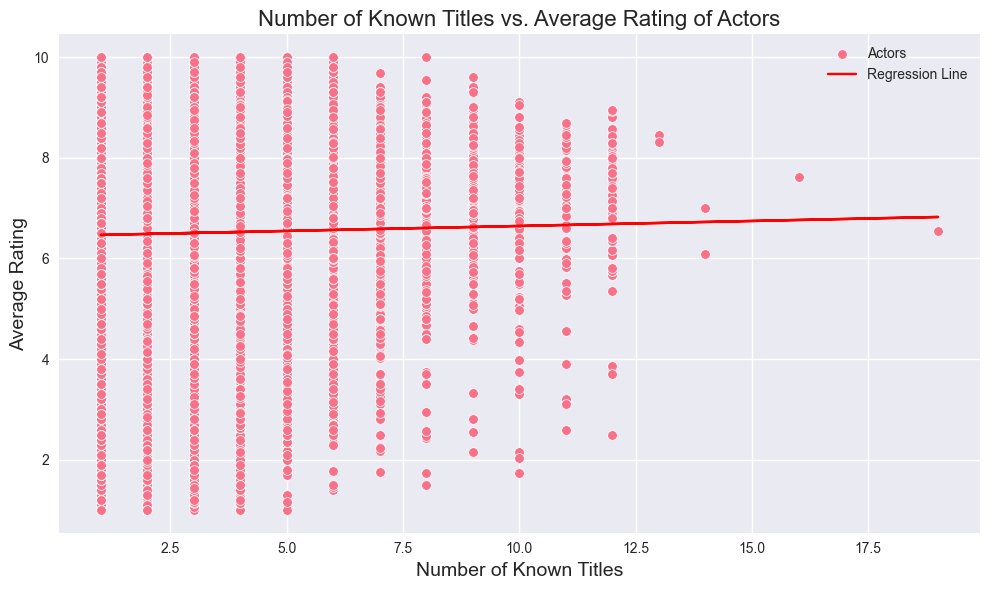

In [ ]:

#  Group by actor 
actor_stats = known_with_ratings.groupby('nconst').agg(
    num_known_titles=('tconst', 'count'),
    avg_rating=('averageRating', 'mean')
).reset_index()

# Merge back names
actor_stats = actor_stats.merge(names_df[['nconst', 'primaryName']], on='nconst', how='left')


# Drop rows with NaN values in either 'num_known_titles' or 'avg_rating'
actor_stats_clean = actor_stats.dropna(subset=['avg_rating', 'num_known_titles'])

# Ensure the data types are numeric
actor_stats_clean['num_known_titles'] = pd.to_numeric(actor_stats_clean['num_known_titles'], errors='coerce')
actor_stats_clean['avg_rating'] = pd.to_numeric(actor_stats_clean['avg_rating'], errors='coerce')

# Prepare clean data for regression
X_clean = actor_stats_clean[['num_known_titles']].values
y_clean = actor_stats_clean['avg_rating'].values

# Initialize and fit the regression model
model = LinearRegression()
model.fit(X_clean, y_clean)

# Output the regression results
y_pred_clean = model.predict(X_clean)
residuals_clean = y_clean - y_pred_clean
r_squared_clean = model.score(X_clean, y_clean)
n_clean = len(X_clean)
p_clean = 1  # number of predictors
adjusted_r_squared_clean = 1 - (1 - r_squared_clean) * (n_clean - 1) / (n_clean - p_clean - 1)

print(f"Coefficient (Slope): {model.coef_[0]:.6f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R-squared: {r_squared_clean:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared_clean:.4f}")
print(f"Standard Error of Residuals: {np.std(residuals_clean):.4f}")

# Statistical significance test
slope, intercept, r_value, p_value, std_err = stats.linregress(
    actor_stats_clean['num_known_titles'], 
    actor_stats_clean['avg_rating']
)
print(f"P-value: {p_value:.6f}")
print(f"Statistical Significance: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")

#  Correlation 
correlation = actor_stats_clean['num_known_titles'].corr(actor_stats_clean['avg_rating'])
print(f"Correlation between number of known titles and average rating: {correlation:.4f}")

# Plot 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=actor_stats_clean, x='num_known_titles', y='avg_rating', label='Actors')
plt.plot(actor_stats_clean['num_known_titles'], model.predict(X_clean), color='red', label='Regression Line')

plt.title('Number of Known Titles vs. Average Rating of Actors', fontsize=16)
plt.xlabel('Number of Known Titles', fontsize=14)
plt.ylabel('Average Rating', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Fame (measured by number of known titles) doesn’t guarantee higher ratings. Acting in many projects doesn’t always mean better average scores.

### Most Prolific Actors

In [ ]:

# Filter actors and actresses
actors_df = principals_df[principals_df['category'].isin(['actor', 'actress'])].copy()

# Merge with names
actors_with_names = pd.merge(actors_df, names_df, on='nconst', how='left')

# Merge with ratings and genres
actor_ratings = pd.merge(actors_with_names, ratings_df, on='tconst', how='left')
actor_ratings = pd.merge(actor_ratings, basics_df[['tconst', 'genres']], on='tconst', how='left')

# Remove entries from genre 'Adult'
actor_ratings_clean = actor_ratings[~actor_ratings['genres'].str.contains('Adult', na=False)]

# Group by actor and calculate statistics
actor_stats = actor_ratings_clean.groupby('nconst').agg(
    num_titles=('tconst', 'count'),
    avg_rating=('averageRating', 'mean'),
    median_rating=('averageRating', 'median'),
    std_rating=('averageRating', 'std'),
    total_votes=('numVotes', 'sum'),
    avg_votes=('numVotes', 'mean'),
    max_rating=('averageRating', 'max'),
    min_rating=('averageRating', 'min')
).reset_index()

actor_stats['std_rating'] = actor_stats['std_rating'].fillna(0)

# Merge again to get actor names
actor_stats = actor_stats.merge(
    names_df[['nconst', 'primaryName', 'primaryProfession', 'knownForTitles']],
    on='nconst', how='left'
)

# Statistical correlation: num_titles vs avg_rating
slope, intercept, r_value, p_value, std_err = stats.linregress(
    actor_stats['num_titles'], actor_stats['avg_rating']
)

# Top prolific actors
print("\nMost Prolific Actors (10+ titles):")
top_prolific_actors = actor_stats[actor_stats['num_titles'] >= 10].nlargest(150, 'num_titles')
for _, row in top_prolific_actors.iterrows():
    name = row['primaryName'] if pd.notna(row['primaryName']) else 'Unknown'
    print(f"  {name}: {row['num_titles']} titles, avg rating: {row['avg_rating']:.2f}")

# Top rated actors (min 5 titles)
print("\nHighest Rated Actors (5+ titles):")
top_rated_actors = actor_stats[actor_stats['num_titles'] >= 5].nlargest(150, 'avg_rating')
for _, row in top_rated_actors.iterrows():
    name = row['primaryName'] if pd.notna(row['primaryName']) else 'Unknown'
    print(f"  {name}: {row['avg_rating']:.2f} avg rating, {row['num_titles']} titles")

# Summary statistics
print("ACTOR SUMMARY STATISTICS")
print("=" * 50)
print(f"Total actors analyzed: {len(actor_stats)}")
print(f"Average projects per actor: {actor_stats['num_titles'].mean():.2f}")
print(f"Median projects per actor: {actor_stats['num_titles'].median():.2f}")
print(f"Average rating across all actors: {actor_stats['avg_rating'].mean():.3f}")
print(f"Standard deviation of average ratings: {actor_stats['avg_rating'].std():.3f}")

# High vs Low volume actors
high_volume_actors = actor_stats[actor_stats['num_titles'] >= actor_stats['num_titles'].quantile(0.8)]
low_volume_actors = actor_stats[actor_stats['num_titles'] <= actor_stats['num_titles'].quantile(0.2)]

print(f"\nHigh-volume actors (atop 20%): avg rating = {high_volume_actors['avg_rating'].mean():.3f}")
print(f"Low-volume actors (bottom 20%): avg rating = {low_volume_actors['avg_rating'].mean():.3f}")



Most Prolific Actors (10+ titles):
  Mel Blanc: 3701 titles, avg rating: 6.54
  Jack Mercer: 1687 titles, avg rating: 6.12
  Jason Young: 1136 titles, avg rating: 6.20
  Brahmanandam: 1135 titles, avg rating: 5.96
  Frank Welker: 978 titles, avg rating: 6.77
  Matsunosuke Onoe: 947 titles, avg rating: 5.78
  Steve Blum: 913 titles, avg rating: 7.11
  Mae Questel: 893 titles, avg rating: 6.32
  Grey Griffin: 875 titles, avg rating: 6.82
  Daws Butler: 837 titles, avg rating: 6.29
  Dee Bradley Baker: 832 titles, avg rating: 6.85
  Jeff Bennett: 756 titles, avg rating: 6.63
  Fred Tatasciore: 737 titles, avg rating: 6.97
  Pinto Colvig: 728 titles, avg rating: 6.43
  Eric Roberts: 724 titles, avg rating: 4.98
  Jim Cummings: 696 titles, avg rating: 6.78
  Jackson Beck: 690 titles, avg rating: 6.29
  Tom Kenny: 687 titles, avg rating: 6.52
  Jagathy Sreekumar: 662 titles, avg rating: 5.57
  Eddie Garcia: 649 titles, avg rating: 6.54
  Adoor Bhasi: 626 titles, avg rating: 6.43
  Paquito D

## ***Top Rated***

### Top 10 Most Voted Movies

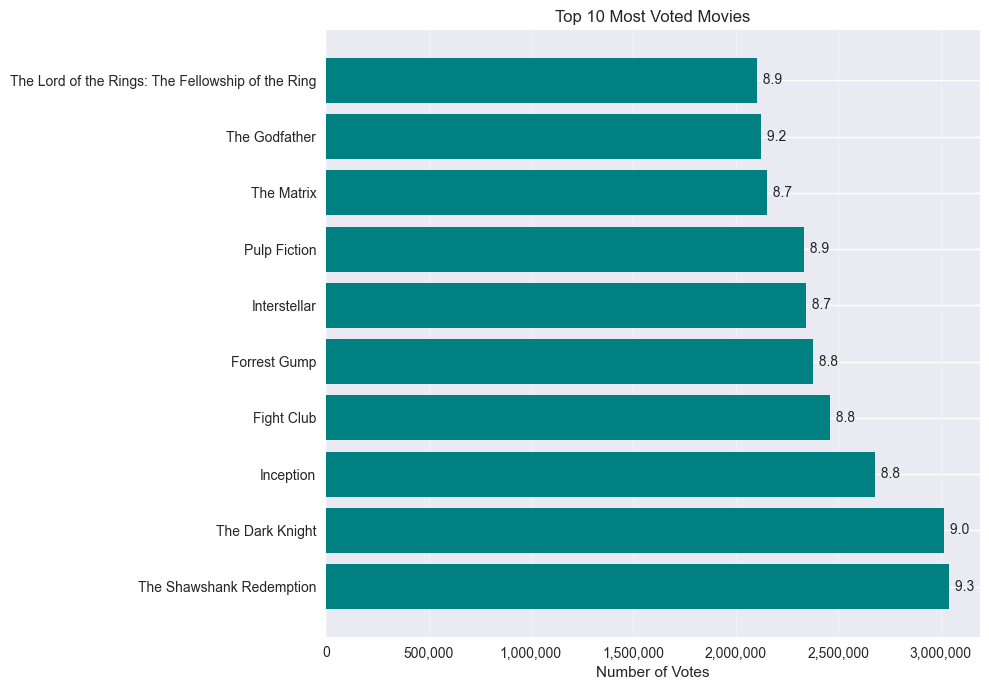

In [ ]:
# Filter only movies
movies_only = rating_analysis[rating_analysis['titleType'] == 'movie']

# Sort and get top 10 most voted movies
top_10_movies = movies_only.sort_values(by='numVotes', ascending=False).head(10)

# Extract titles, votes, and ratings
titles = top_10_movies['primaryTitle']
votes = top_10_movies['numVotes']
ratings = top_10_movies['averageRating']

# Plot
plt.figure(figsize=(10, 7))
bars = plt.barh(titles, votes, color='teal')
plt.xlabel('Number of Votes')
plt.title('Top 10 Most Voted Movies')

# Format x-axis with commas
formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
plt.gca().xaxis.set_major_formatter(formatter)

# Add rating labels
for bar, rating in zip(bars, ratings):
    width = bar.get_width()
    plt.text(width + 10000, bar.get_y() + bar.get_height()/2, f' {rating:.1f}', va='center')

plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Top 10 Most Voted TVseries

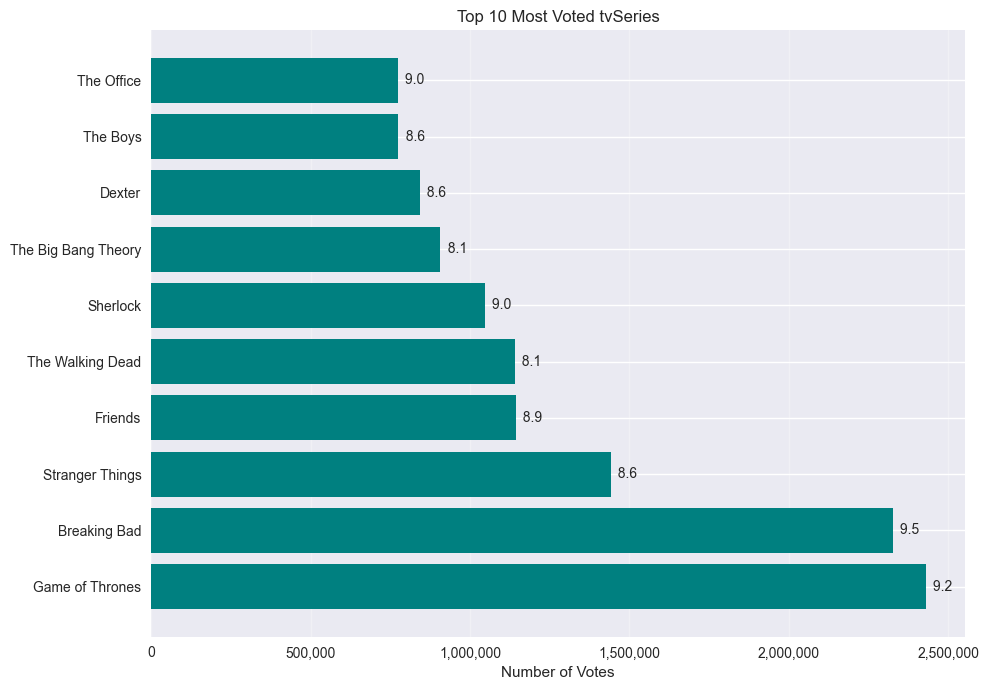

In [77]:
# Filter only movies
movies_only = rating_analysis[rating_analysis['titleType'] == 'tvSeries']

# Sort and get top 10 most voted movies
top_10_movies = movies_only.sort_values(by='numVotes', ascending=False).head(10)

# Extract titles, votes, and ratings
titles = top_10_movies['primaryTitle']
votes = top_10_movies['numVotes']
ratings = top_10_movies['averageRating']

# Plot
plt.figure(figsize=(10, 7))
bars = plt.barh(titles, votes, color='teal')
plt.xlabel('Number of Votes')
plt.title('Top 10 Most Voted tvSeries')

# Format x-axis with commas
formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
plt.gca().xaxis.set_major_formatter(formatter)

# Add rating labels
for bar, rating in zip(bars, ratings):
    width = bar.get_width()
    plt.text(width + 10000, bar.get_y() + bar.get_height()/2, f' {rating:.1f}', va='center')

plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# **Key Insights**

After analyzing the IMDb data, a few clear patterns stood out across different types of content, viewer behavior, and creator influence:
Over the years, especially in the 2010s, there was a massive increase in the number of titles being produced  with short films leading the charge. This probably has a lot to do with the rise of platforms like YouTube and Vimeo, which made it easier than ever for people to create and share short content. That momentum slowed around 2020, likely due to COVID-19 affecting productions worldwide.
Shorts, documentaries, and dramas have become some of the most common genres in recent years. Interestingly, the top-rated genre combinations almost always include documentaries  especially when paired with topics like sport, music, or history. This suggests that people really value real, meaningful stories.
Voting on IMDb took off in the early 2000s and peaked between 2015 and 2019. After that, there was a noticeable drop  again, likely tied to the pandemic or shifts in user habits. We also noticed that titles with fewer votes tend to have more extreme ratings, while the more popular ones usually fall somewhere between 6 and 8. So, more votes = more balanced ratings.
Mini-series and shorts consistently get higher average ratings than full-length movies, but movies still get the most votes overall. This shows that while shorter formats are often appreciated more, movies still grab the most attention.
When we looked at directors and actors, we found something interesting  having more projects doesn’t automatically mean better ratings. A few directors with tons of work do have good scores, but for most, there’s no strong connection. Same goes for actors: being in more well-known titles doesn’t always lead to higher ratings.